# Notebook 4 — EEM vs DXY: Comparative Analysis

**Bachelor thesis:** Testing Market Efficiency: Evidence from the US Dollar Index and Emerging Markets

---

**Run order:** run **DXY_part** and **EMCI_part** notebooks **01 → 02 → 03** first (processed data and predictions). Use the **repository root** as the working directory. Optional: **`05_appendix.ipynb`** for thesis appendix tables (starts at Appendix **B**).

This notebook produces paired thesis-quality charts comparing:
- **EEM** — MSCI Emerging Markets ETF (studied in EMCI_part)
- **DXY** — US Dollar Index (studied in DXY_part)

Log-returns, Lasso forecasts, and model artifacts load from disk (no model re-runs).
**Adjusted close prices** for Figure 1 are downloaded via **yfinance** (same tickers as NB01:
`EEM`, `DX-Y.NYB`).

| Section | Content |
|---------|---------|
| 1 | Data Loading |
| 2 | Thesis Visualizations (15 figures + GARCH diagnostics + volatility panels) |

Output figures saved as **vector PDF** in `reports/figures/` (scalable for print/thesis). Base font size **14**; tick labels **12**; legend **12**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import yfinance as yf

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT   = Path('.')                          # DIPLOM/
EMCI   = ROOT / 'EMCI_part'
DXY_P  = ROOT / 'DXY_part'
OUTDIR = ROOT / 'reports' / 'figures'
OUTDIR.mkdir(parents=True, exist_ok=True)

# Human-readable feature names (Yahoo tickers → thesis labels; shared by Figs. 11, 12, 18).
FEATURE_TICKER_LABELS = {
    "^VIX": "VIX",
    "^TNX": "TNX",
    "^GSPC": "S&P 500",
    "CL=F": "WTI Oil",
    "HG=F": "Copper",
    "GC=F": "Gold",
    "GBPUSD=X": "GBP/USD",
    "EURUSD=X": "EUR/USD",
    "JPY=X": "USD/JPY",
    "CAD=X": "USD/CAD",
    "DX-Y.NYB": "DXY",
    "EEM": "EEM",
}

def thesis_feature_label(raw: str, *, own_target: str) -> str:
    """Map internal feature column name to thesis wording.
    own_target: 'EEM' or 'DXY' — which asset's lags `target_lag*` refer to.
    """
    if raw in FEATURE_TICKER_LABELS:
        return FEATURE_TICKER_LABELS[raw]
    if raw.startswith("target_lag"):
        lag = raw.replace("target_lag", "")
        return f"lag {lag}"
    if raw == "vol_21":
        return "vol. 21d"
    if raw == "vol_63":
        return "vol. 63d"
    return raw

sns.set_theme(
    style='whitegrid',
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor':   'white',
        'axes.titleweight': 'normal',
        'figure.titleweight': 'normal',
        'legend.fontsize': 12,
    },
)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        14,
    'axes.titlesize':   14,
    'axes.labelsize':   14,
    'axes.titleweight': 'normal',
    'xtick.labelsize':  14,
    'ytick.labelsize':  14,
    'legend.fontsize':  14,
    'figure.titlesize': 14,
    'figure.titleweight': 'normal',
    'pdf.fonttype':     42,
    'svg.fonttype':     'none',
})
# Seaborn default theme is darkgrid (grey axes); use whitegrid + same rc as matplotlib


print("Imports OK")
print(f"Output figures -> {OUTDIR.resolve()}")



Imports OK
Output figures -> C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures


## 1. Data Loading

Load log-return series, Lasso OOS forecasts, and RF/GB feature importances from disk.
Fetch **Adj Close** for EEM and DX-Y.NYB via **yfinance**, aligned to the common return calendar.


In [2]:
# ── Returns ────────────────────────────────────────────────────────────────
eem_ret = pd.read_csv(EMCI / 'data/processed/eem_dataset_target.csv',
                      index_col='Date', parse_dates=True)['target']
dxy_ret = pd.read_csv(DXY_P / 'data/processed/dxy_dataset_target.csv',
                      index_col='Date', parse_dates=True)['target']

common_all = eem_ret.index.intersection(dxy_ret.index)
eem_c = eem_ret.loc[common_all].dropna()
dxy_c = dxy_ret.loc[common_all].dropna()
common_all = eem_c.index.intersection(dxy_c.index)
eem_c = eem_c.loc[common_all]
dxy_c = dxy_c.loc[common_all]

# Fixed sample end (same as EMCI_part / DXY_part config.data.end_date)
SAMPLE_END = pd.Timestamp("2026-03-31")
common_all = common_all[common_all <= SAMPLE_END]
eem_c = eem_c.loc[common_all]
dxy_c = dxy_c.loc[common_all]

print(f"Common return series: {len(common_all)} days  "
      f"({common_all.min().date()} to {common_all.max().date()})")

# ── Cumulative return indices ───────────────────────────────────────────────
eem_cum = np.exp(eem_c.cumsum())
dxy_cum = np.exp(dxy_c.cumsum())

# ── Lasso OOS forecasts ────────────────────────────────────────────────────
lasso_eem = pd.read_csv(EMCI / 'data/processed/lasso_predictions.csv',
                        index_col=0, parse_dates=True)
lasso_dxy = pd.read_csv(DXY_P / 'data/processed/lasso_predictions.csv',
                        index_col=0, parse_dates=True)

lasso_eem = lasso_eem.loc[lasso_eem.index <= SAMPLE_END]
lasso_dxy = lasso_dxy.loc[lasso_dxy.index <= SAMPLE_END]

print(f"EEM Lasso OOS: {len(lasso_eem)} rows  "
      f"({lasso_eem.index.min().date()} to {lasso_eem.index.max().date()})")
print(f"DXY Lasso OOS: {len(lasso_dxy)} rows  "
      f"({lasso_dxy.index.min().date()} to {lasso_dxy.index.max().date()})")

# ── Feature importances from pkl ───────────────────────────────────────────
def load_importances(pkl_path):
    with open(pkl_path, 'rb') as fh:
        p = pickle.load(fh)
    names = p.get('feature_names') or []
    imp   = p['fitted_estimator'].feature_importances_
    return pd.Series(imp, index=names).sort_values(ascending=False)

eem_rf_imp = load_importances(EMCI / 'models/saved/rf_model.pkl')
eem_gb_imp = load_importances(EMCI / 'models/saved/gb_model.pkl')
dxy_rf_imp = load_importances(DXY_P / 'models/saved/rf_model.pkl')
dxy_gb_imp = load_importances(DXY_P / 'models/saved/gb_model.pkl')

# ── Ridge / Lasso: |coefficients| on standardized features (same as NB02) ───
def load_abs_coefs(pkl_path):
    with open(pkl_path, 'rb') as fh:
        d = pickle.load(fh)
    names = list(d['feature_names'])
    coef = np.asarray(d['model'].coef_, dtype=float).ravel()
    return pd.Series(np.abs(coef), index=names).sort_values(ascending=False)

eem_ridge_abs = load_abs_coefs(EMCI / 'models/saved/ridge_model.pkl')
eem_lasso_abs = load_abs_coefs(EMCI / 'models/saved/lasso_model.pkl')
dxy_ridge_abs = load_abs_coefs(DXY_P / 'models/saved/ridge_model.pkl')
dxy_lasso_abs = load_abs_coefs(DXY_P / 'models/saved/lasso_model.pkl')
print(f"Ridge/Lasso |coef| series: EEM {len(eem_ridge_abs)}, DXY {len(dxy_ridge_abs)} features")

# ── Adjusted close prices (Yahoo Finance), aligned to common return calendar ─
def _yf_adj_close(ticker, start_d, end_d):
    """Download Adj Close; return tz-naive daily Series."""
    df = yf.download(ticker, start=start_d, end=end_d, progress=False, auto_adjust=False)
    if df.empty:
        raise RuntimeError(f"yfinance returned no data for {ticker}")
    if isinstance(df.columns, pd.MultiIndex):
        s = df["Adj Close"]
        if isinstance(s, pd.DataFrame):
            s = s.squeeze(axis=1)
    else:
        s = df["Adj Close"] if "Adj Close" in df.columns else df["Close"]
    s = s.dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None).normalize()
    return s.sort_index()

_p_start = (common_all.min() - pd.Timedelta(days=7)).strftime("%Y-%m-%d")
_p_end = (SAMPLE_END + pd.Timedelta(days=7)).strftime("%Y-%m-%d")
eem_price = _yf_adj_close("EEM", _p_start, _p_end)
dxy_price = _yf_adj_close("DX-Y.NYB", _p_start, _p_end)
eem_px_c = eem_price.reindex(common_all).ffill().bfill()
dxy_px_c = dxy_price.reindex(common_all).ffill().bfill()
_ok = eem_px_c.notna() & dxy_px_c.notna()
eem_px_c, dxy_px_c = eem_px_c.loc[_ok], dxy_px_c.loc[_ok]
print(
    f"Adj Close aligned: {len(eem_px_c)} days  "
    f"({eem_px_c.index.min().date()} to {eem_px_c.index.max().date()})"
)

print(f"EEM RF features: {len(eem_rf_imp)}")
print(f"DXY RF features: {len(dxy_rf_imp)}")
print("All data loaded.")

Common return series: 5319 days  (2005-02-01 to 2026-03-30)
EEM Lasso OOS: 1052 rows  (2022-01-19 to 2026-03-30)
DXY Lasso OOS: 1053 rows  (2022-01-20 to 2026-03-30)
Ridge/Lasso |coef| series: EEM 15, DXY 15 features
Adj Close aligned: 5319 days  (2005-02-01 to 2026-03-30)
EEM RF features: 15
DXY RF features: 15
All data loaded.


---
## 2. Thesis Visualizations

| Figure | Layout | Title |
|--------|--------|-------|
| 1 | Single chart, dual y-axis | Adjusted Close Price Levels: EEM vs DXY |
| 2 | Dual y-axis | Cumulative Return Index: EEM vs DXY |
| 3 | 2 vertical panels (shared date axis) | Daily Log-Returns |
| 4 | Single overlay | Return Distribution |
| 5 | 2 horizontal subplots | Q-Q Plot vs Normal Distribution |
| 6 | Single chart | Rolling 63-Day Annualized Volatility |
| 7 | Single chart | Rolling 63-Day Correlation: EEM vs DXY |
| 8 | Scatter + regression | EEM vs DXY Daily Returns |
| 9 | 2 horizontal subplots | ACF of Returns |
| 10 | 2 horizontal subplots | Lasso OOS Forecasts vs Actual |
| 11 | 2 horizontal subplots | RF Feature Importance |
| 12 | Heatmap (12×12) | Pearson correlation: EEM, DXY, 10 exogenous returns |
| 13 | 2 horizontal subplots | PACF of log-returns (40 lags) |
| 14 | Single wide chart | Return distribution boxplots (12 series) |
| 15 | Small-multiples grid | Cross-asset daily log-returns |
| 16–17 | GARCH diagnostics | See sections below (two-step residuals, returns & vol) |
| 18 | 2×2 subplots | Ridge & Lasso abs. coefficients (EEM / DXY, four panels) |
| 19 | 2 vertical subplots | Rolling OOS Forecasts — ARIMA+GARCH, ARIMAX, joint ARX, Ridge/Lasso, ML (stacked EEM / DXY) |
| 20 | 2×N subplots | Block Permutation Test — permuted RMSE distributions vs real RMSE (top: EEM, bottom: DXY) |


### Figure 1 — Adjusted Close Price Levels: EEM vs DXY (2005–2026)

**What it shows:** Daily **adjusted** closing prices (Yahoo Finance) for **EEM** (MSCI EM ETF) and **DX-Y.NYB** (ICE US Dollar Index continuous futures — the same DXY proxy used elsewhere in the project). **One time series chart with dual y-axes:** EEM on the **left** (USD per share) and DX-Y.NYB on the **right** (index points). The **x-axis** is shared; values on the two vertical scales are **not directly comparable**.

**Thesis use:** Full-sample price path *before* any re-basing. Major episodes (2008, 2020, etc.) are visible in level space. The cumulative return index (Figure 2) then normalizes both series to a common starting wealth of 1.


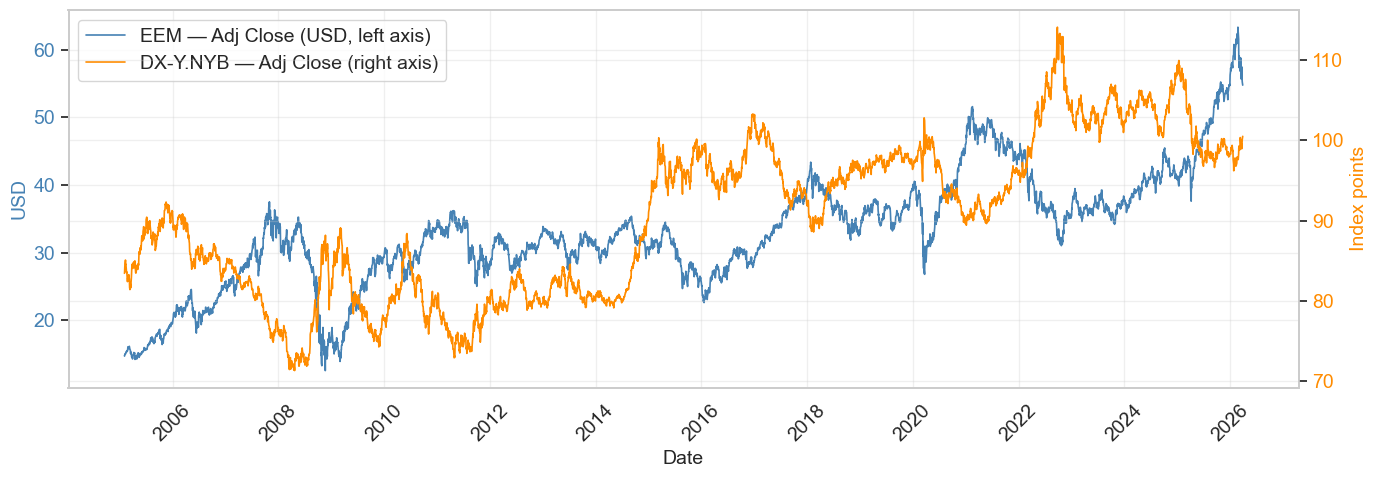

Fig 1 (price levels) saved.


In [3]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(
    eem_px_c.index,
    eem_px_c.values,
    color="steelblue",
    lw=1.2,
    label="EEM — Adj Close (USD, left axis)")
ax2.plot(
    dxy_px_c.index,
    dxy_px_c.values,
    color="darkorange",
    lw=1.2,
    label="DX-Y.NYB — Adj Close (right axis)")

ax1.set_ylabel("USD", color="steelblue")
ax2.set_ylabel("Index points", color="darkorange")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax1.set_xlabel("Date")

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")


plt.tight_layout()
plt.savefig(OUTDIR / "comp_fig1_price_levels.pdf", bbox_inches="tight")
plt.show()
print("Fig 1 (price levels) saved.")




### Figure 2 — Cumulative Return Index: EEM vs DXY (2005–2026)

**What it shows:** Wealth evolution of $1 invested in EEM and DXY at the start
of the sample. Dual y-axes because the two indices diverge substantially.
EEM multiplied ~5x; DXY is mean-reverting — exactly the asymmetry this thesis
needs to motivate studying them separately.

**Thesis use:** Follows Figure 1 (price levels). Re-bases both series to wealth = 1
at the start of the common sample so relative performance is comparable despite
different units. Illustrates the inverse relationship: EEM peaks coincide with DXY
troughs (2007–2008, 2020–2021) and vice versa.


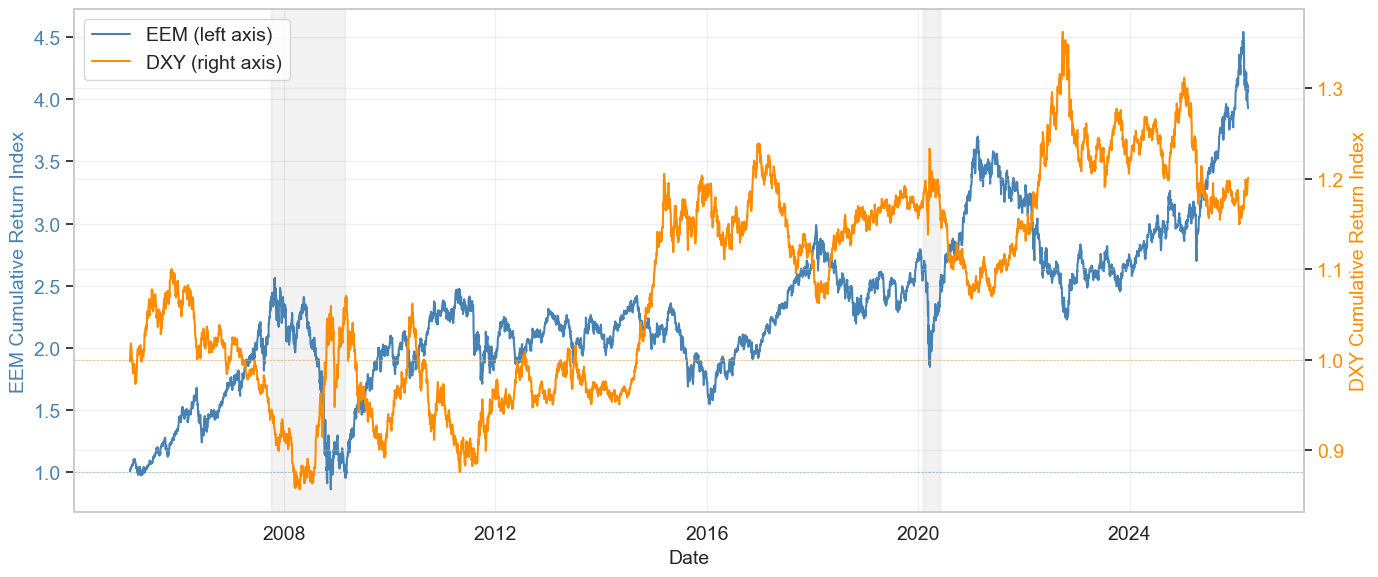

Fig 2 saved.


In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(eem_cum.index, eem_cum.values,
         color='steelblue', lw=1.5, label='EEM (left axis)')
ax2.plot(dxy_cum.index, dxy_cum.values,
         color='darkorange', lw=1.5, label='DXY (right axis)')

ax1.axhline(1, color='steelblue', lw=0.5, linestyle='--', alpha=0.5)
ax2.axhline(1, color='darkorange', lw=0.5, linestyle='--', alpha=0.5)

# Crisis shading
crises = [('2007-10-01', '2009-03-01', 'GFC'),
          ('2020-02-01', '2020-06-01', 'COVID')]
for s, e, lbl in crises:
    ax1.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                alpha=0.10, color='gray', label=f'_{lbl}')

ax1.set_ylabel('EEM Cumulative Return Index', color='steelblue')
ax2.set_ylabel('DXY Cumulative Return Index', color='darkorange')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax1.set_xlabel('Date')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig2_cumulative_returns.pdf', bbox_inches='tight')
plt.show()
print("Fig 2 saved.")




### Figure 3 — Daily Log-Returns: EEM vs DXY

**What it shows:** Two **stacked** time-series panels with a **shared horizontal
(date) axis**: EEM above, DXY below. Each panel plots daily log-returns (%)
as a thin line with light shading above/below zero (positive vs negative days).
This layout matches common practice in applied papers: long samples stay readable,
and crises align vertically across assets without squeezing both series into
one y-scale.

**Thesis use:** Motivates GARCH modelling for both series — clearly visible
volatility clustering and asymmetric spikes.


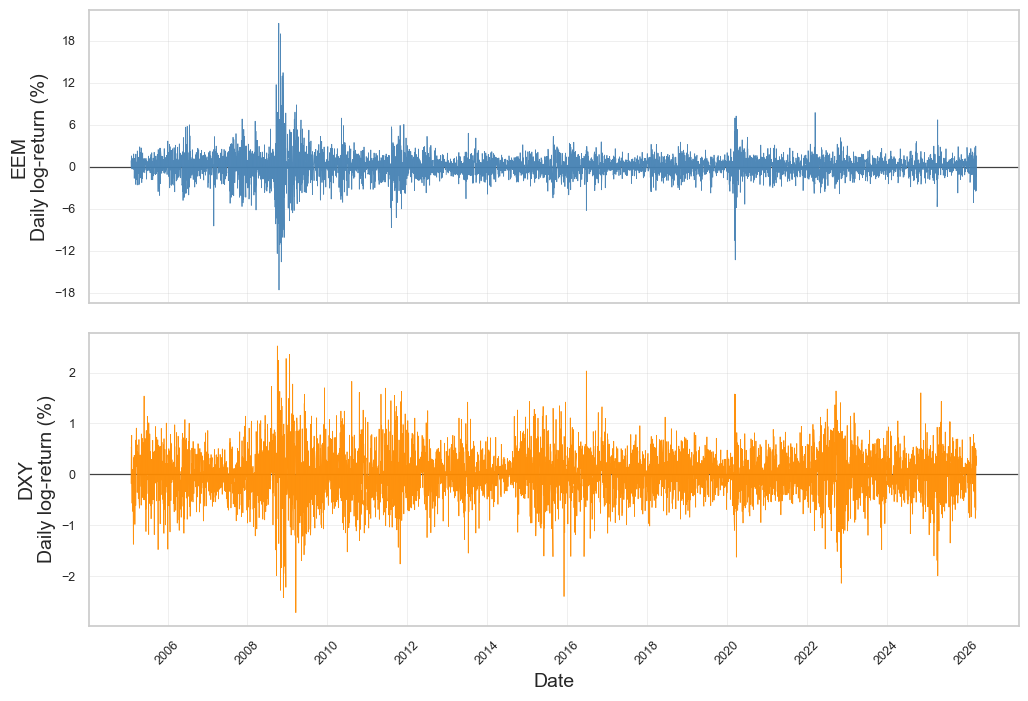

Fig 3 saved.


In [5]:
fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"hspace": 0.10, "height_ratios": [1, 1]})

for ax, ret, color, name in [
    (axes[0], eem_c, "steelblue", "EEM"),
    (axes[1], dxy_c, "darkorange", "DXY"),
]:
    y = ret * 100
    ax.axhline(0, color="0.25", lw=0.9, zorder=1)
    ax.plot(
        ret.index,
        y.values,
        color=color,
        lw=0.55,
        alpha=0.95,
        zorder=3,
        clip_on=False)
    ax.fill_between(
        ret.index,
        y.values,
        0,
        where=(y.values >= 0),
        color=color,
        alpha=0.20,
        linewidth=0,
        zorder=0)
    ax.fill_between(
        ret.index,
        y.values,
        0,
        where=(y.values < 0),
        color="0.5",
        alpha=0.18,
        linewidth=0,
        zorder=0)
    ax.set_ylabel(f"{name}\nDaily log-return (%)")
    ax.grid(True, alpha=0.35, linestyle="-", linewidth=0.5, color="0.75")
    ax.tick_params(axis="both", labelsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=7, prune=None))

axes[0].tick_params(axis="x", labelbottom=False)
axes[1].set_xlabel("Date")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(OUTDIR / "comp_fig3_daily_returns.pdf", bbox_inches="tight")
plt.show()
print("Fig 3 saved.")




### Figure 4 — Return Distribution Overlay: EEM vs DXY

**What it shows:** Kernel density estimates of daily log-returns on the same axes.
Both assets have fat tails relative to a Normal distribution; EEM has a wider
spread (higher volatility), while DXY is more concentrated but still leptokurtic.

**Thesis use:** Justifies using Student-t distribution in GARCH for both assets.
The overlapping KDEs also highlight the fundamental difference in risk profiles.


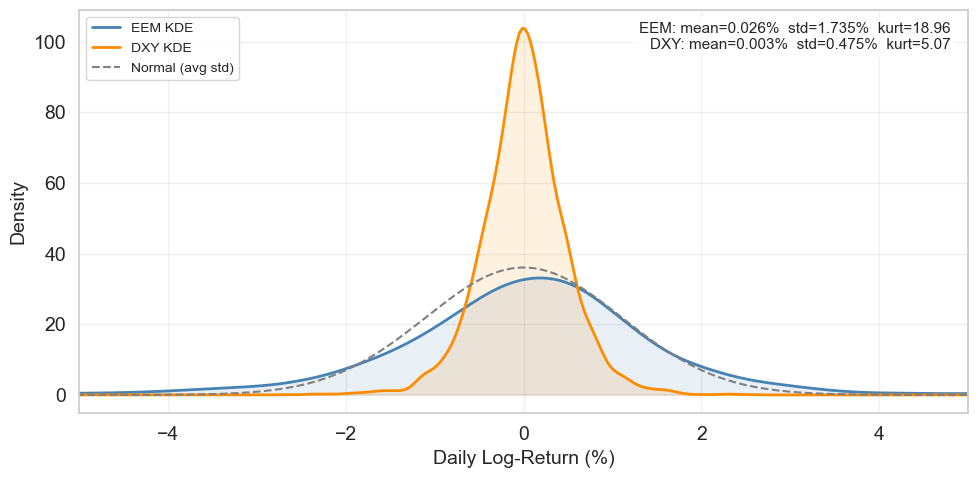

Fig 4 saved.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.linspace(-0.06, 0.06, 400)

for ret, color, name in [(eem_c, 'steelblue', 'EEM'), (dxy_c, 'darkorange', 'DXY')]:
    kde = gaussian_kde(ret, bw_method='scott')
    ax.plot(x * 100, kde(x), color=color, lw=2, label=f'{name} KDE')
    ax.fill_between(x * 100, kde(x), alpha=0.12, color=color)

# Normal reference
mu, sig = 0, np.mean([eem_c.std(), dxy_c.std()])
norm_pdf = sp_stats.norm.pdf(x, mu, sig)
ax.plot(x * 100, norm_pdf, color='gray', lw=1.5, linestyle='--',
        label='Normal (avg std)')

ax.set_xlabel('Daily Log-Return (%)', fontsize = 14)
ax.set_ylabel('Density', fontsize = 14)
ax.legend(fontsize = 10)
ax.set_xlim(-5, 5)

stats_text = (
    f"EEM: mean={eem_c.mean()*100:.3f}%  std={eem_c.std()*100:.3f}%  kurt={eem_c.kurt() + 3:.2f}"
    + "\n"
    + f"DXY: mean={dxy_c.mean()*100:.3f}%  std={dxy_c.std()*100:.3f}%  kurt={dxy_c.kurt() + 3:.2f}"
)
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize = 11)

plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig4_distribution.pdf', bbox_inches='tight')
plt.show()
print("Fig 4 saved.")





### Figure 5 — Q-Q Plot: EEM and DXY Returns vs Normal Distribution

**What it shows:** Quantile-quantile plots compare the empirical distribution of
daily log-returns against the theoretical Normal distribution. Points lying above
the line in the upper tail and below the line in the lower tail indicate
**fat tails** (leptokurtosis) — the defining stylised fact of financial returns.

**Why two panels:** Allows direct visual comparison: EEM has markedly fatter tails
(higher kurtosis) reflecting emerging-market risk episodes, while DXY deviates
less but still significantly — confirming non-normality for both series.

**Thesis use:** Quantitative justification for using Student-t innovations in
GARCH models rather than assuming normality. Complements the KDE overlay in Figure 4 with a more precise statistical diagnostic.

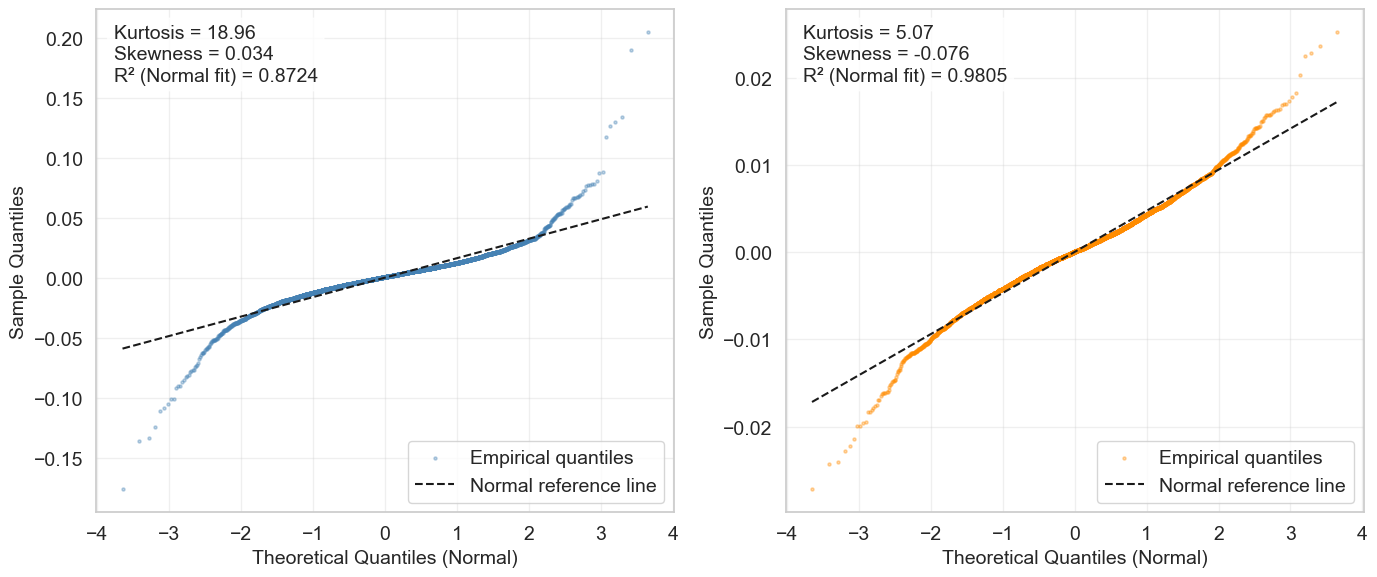

Fig 5 saved.


In [7]:
from scipy.stats import probplot

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, ret, color, name in [
    (axes[0], eem_c, 'steelblue', 'EEM'),
    (axes[1], dxy_c, 'darkorange', 'DXY')
]:
    (osm, osr), (slope, intercept, r) = probplot(ret, dist='norm', fit=True)

    ax.scatter(osm, osr, s=5, alpha=0.35, color=color, zorder=2,
               label='Empirical quantiles')

    line_x = np.array([osm[0], osm[-1]])
    ax.plot(line_x, slope * line_x + intercept, 'k--', lw=1.5, zorder=3,
            label='Normal reference line')

    kurt_val = ret.kurt()
    skew_val = ret.skew()
    stats_str = (f'Kurtosis = {kurt_val+3:.2f}\n'
                 f'Skewness = {skew_val:.3f}\n'
                 f'R² (Normal fit) = {r**2:.4f}')
    ax.text(0.03, 0.97, stats_str, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('Theoretical Quantiles (Normal)')
    ax.set_ylabel('Sample Quantiles')
    ax.legend()

plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig5_qqplot.pdf', bbox_inches='tight')
plt.show()
print("Fig 5 saved.")





### Figure 6 — Rolling 63-Day Annualized Volatility: EEM vs DXY

**What it shows:** 63-trading-day rolling standard deviation annualized to
percentage. Both series on the same axis — EEM's volatility is consistently
higher, but the crisis synchronization is clear (both spike in 2008 and 2020).

**Thesis use:** Confirms that both markets share volatility regimes driven by
global macro shocks, despite their directional independence. Justifies using
GARCH on both series.


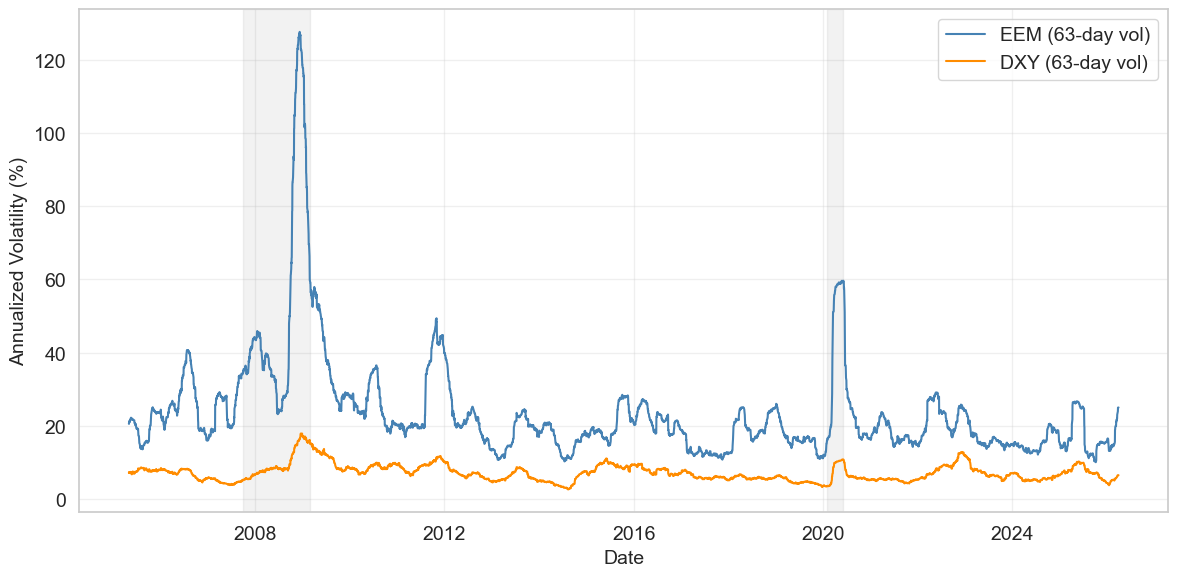

Fig 6 saved.


In [8]:
window = 63
eem_vol = eem_c.rolling(window).std() * np.sqrt(252) * 100
dxy_vol = dxy_c.rolling(window).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(eem_vol.index, eem_vol.values, color='steelblue', lw=1.5, label='EEM (63-day vol)')
ax.plot(dxy_vol.index, dxy_vol.values, color='darkorange', lw=1.5, label='DXY (63-day vol)')

for s, e, lbl in crises:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.10, color='gray')

ax.set_ylabel('Annualized Volatility (%)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig6_rolling_vol.pdf', bbox_inches='tight')
plt.show()
print("Fig 6 saved.")




### Figure 7 — Rolling 63-Day Correlation: EEM vs DXY Returns

**What it shows:** Pearson correlation between EEM and DXY daily log-returns
computed over a rolling 63-trading-day window. This chart does not appear in
either individual notebook — it is unique to the comparative analysis.

**Thesis use:** Demonstrates that the EEM–DXY relationship is not constant.
During crises the correlation becomes strongly negative (dollar safe-haven
demand crushes EM assets). In calm periods it reverts toward zero. This
regime-dependence motivates studying both assets and justifies the EMH
framework: even knowing DXY improves EEM forecasts only marginally.


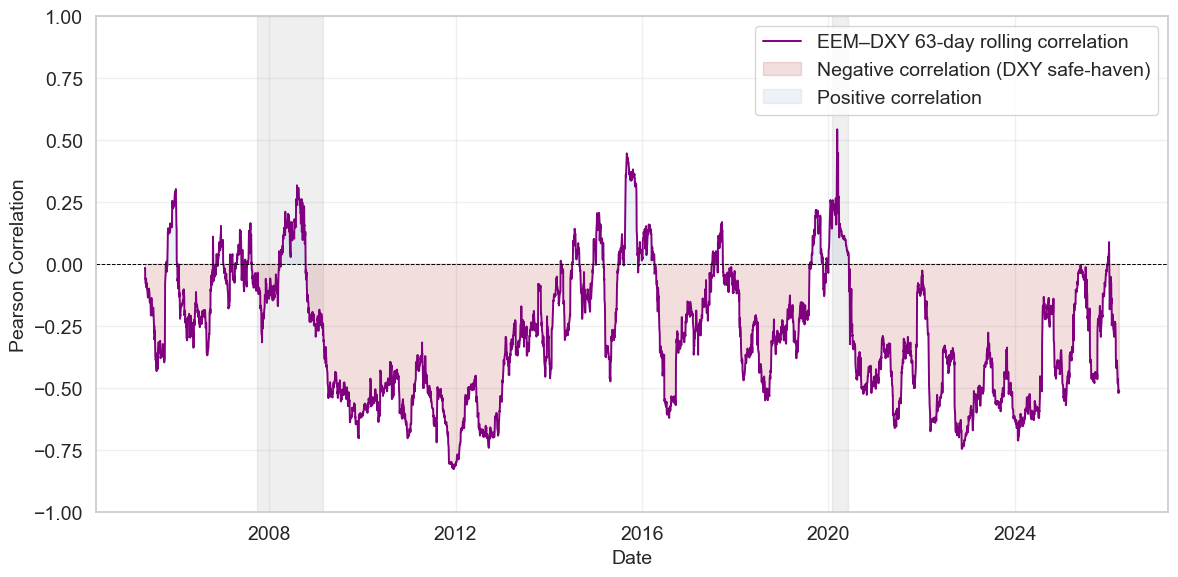

Fig 7 saved.


In [9]:
roll_corr = eem_c.rolling(window).corr(dxy_c)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(roll_corr.index, roll_corr.values, color='purple', lw=1.4,
        label='EEM–DXY 63-day rolling correlation')
ax.axhline(0, color='black', lw=0.7, linestyle='--')
ax.fill_between(roll_corr.index, roll_corr.values, 0,
                where=(roll_corr.values < 0), color='firebrick', alpha=0.15,
                label='Negative correlation (DXY safe-haven)')
ax.fill_between(roll_corr.index, roll_corr.values, 0,
                where=(roll_corr.values >= 0), color='steelblue', alpha=0.10,
                label='Positive correlation')

for s, e, lbl in crises:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.12, color='gray')

ax.set_ylabel('Pearson Correlation')
ax.set_xlabel('Date')
ax.set_ylim(-1, 1)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig7_rolling_corr.pdf', bbox_inches='tight')
plt.show()
print("Fig 7 saved.")




### Figure 8 — Scatter: EEM vs DXY Daily Returns

**What it shows:** Each point is one trading day, with DXY return on the x-axis
and EEM return on the y-axis. An OLS regression line with 95% confidence band
is overlaid. Points are color-coded by year to reveal time-varying structure.

**Thesis use:** Visually confirms the statistically significant negative beta
(DXY appreciation → EM sell-off). The wide scatter around the regression line
explains why ARIMAX with DXY as an exogenous variable for EEM (or vice versa)
still leaves most variance unexplained — consistent with EMH findings.


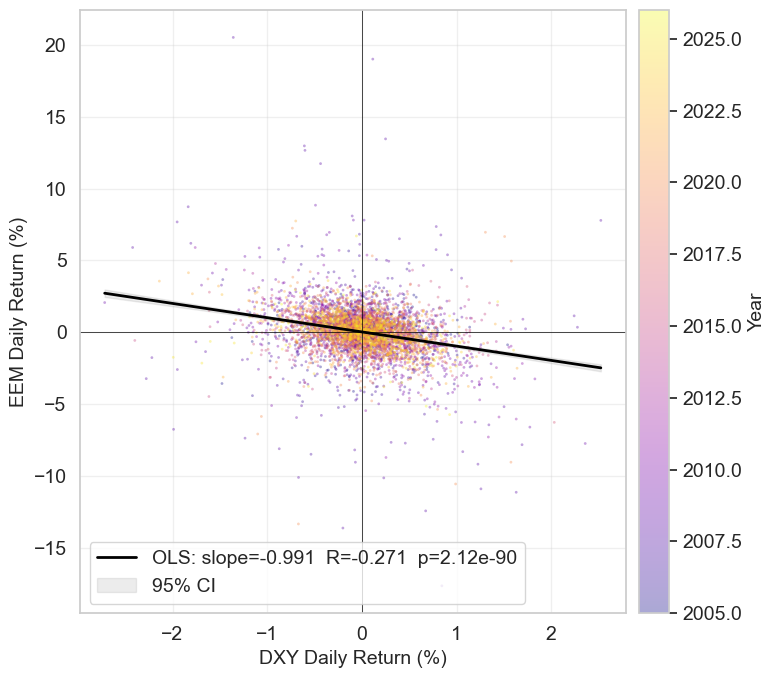

Fig 8 saved.


In [10]:
x = dxy_c.values * 100
y = eem_c.values * 100

# OLS fit
slope, intercept, r, p_val, se = sp_stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

# 95% CI band
n     = len(x)
x_bar = x.mean()
s_err = np.sqrt(np.sum((y - (slope * x + intercept))**2) / (n - 2))
ci    = sp_stats.t.ppf(0.975, df=n - 2) * s_err * np.sqrt(
            1/n + (x_line - x_bar)**2 / np.sum((x - x_bar)**2))

# Year color coding
years = pd.DatetimeIndex(common_all).year.values
year_min, year_max = years.min(), years.max()
norm  = plt.Normalize(year_min, year_max)
cmap  = plt.cm.plasma

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(x, y, c=years, cmap=cmap, norm=norm,
                s=4, alpha=0.35, linewidths=0)
ax.plot(x_line, y_line, color='black', lw=2,
        label=f'OLS: slope={slope:.3f}  R={r:.3f}  p={p_val:.2e}')
ax.fill_between(x_line, y_line - ci, y_line + ci,
                alpha=0.15, color='gray', label='95% CI')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Year')

ax.set_xlabel('DXY Daily Return (%)')
ax.set_ylabel('EEM Daily Return (%)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig8_scatter.pdf', bbox_inches='tight')
plt.show()
print("Fig 8 saved.")





### Figure 9 — ACF of Log-Returns: EEM vs DXY

**What it shows:** Autocorrelation Function (40 lags) of raw log-returns for
each asset plotted side by side. Blue shaded bands are 95% confidence intervals
under white noise.

**Thesis use:** Differences in ACF structure motivate different ARIMA orders
for each asset. If DXY shows more significant lags, its auto_arima will select
a higher AR/MA order than EEM's, validating the two-step approach used in
NB02 for each project.


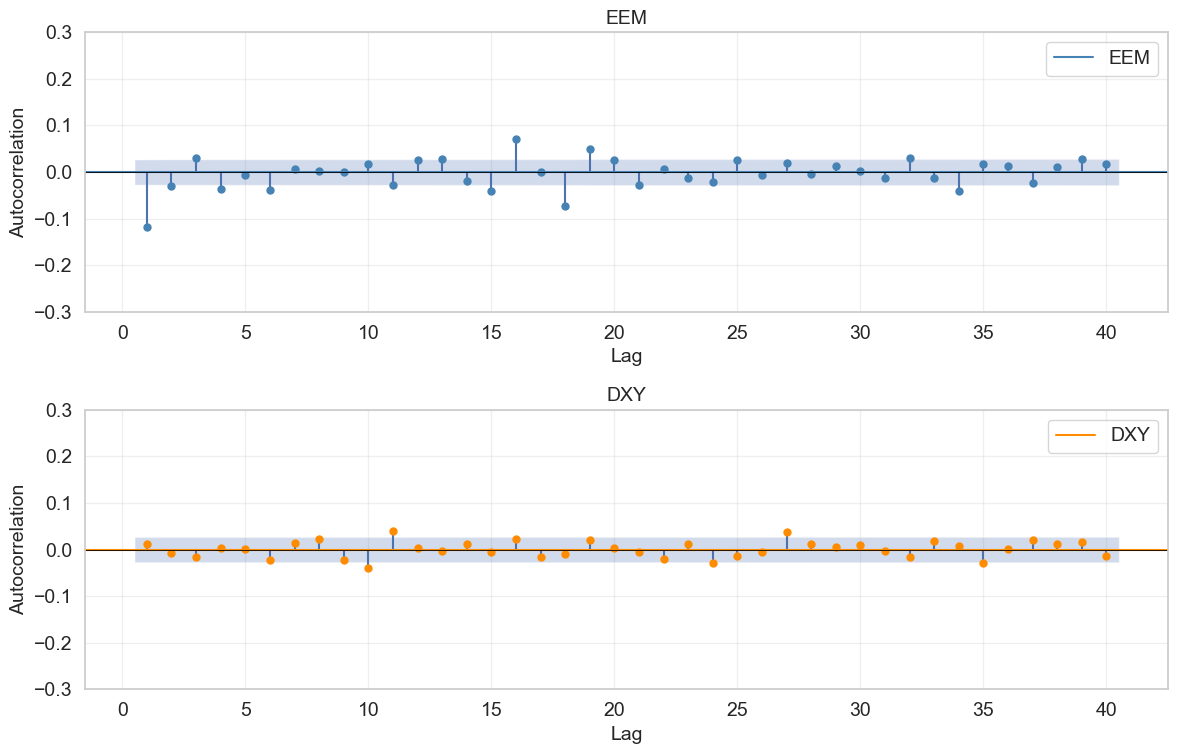

Fig 9 saved.


In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

for ax, ret, color, name in [
    (ax1, eem_c, 'steelblue', 'EEM'),
    (ax2, dxy_c, 'darkorange', 'DXY'),
]:
    plot_acf(ret.values, lags=40, ax=ax, zero=False,
             alpha=0.05, color=color, title=f'{name}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.axhline(0, color='black', lw=0.6)
    # Dummy line for legend (empty plot)
    ax.plot([], [], color=color, label=name)
    ax.legend()
    ax.set_ylim(-0.3, 0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTDIR / 'comp_fig9_acf.pdf', bbox_inches='tight')
plt.show()
print("Fig 9 saved.")




### Figure 10 — Lasso OOS Forecasts vs Actual: EEM vs DXY

**What it shows:** Side-by-side panels showing Lasso rolling out-of-sample
predictions (colored line) against realized returns (gray) for each asset.
Both panels share the same y-scale for a fair visual comparison of forecast
accuracy levels.

**Thesis use:** A direct cross-asset comparison of how well the Lasso model
fits each market. If DXY Lasso forecasts are flatter (closer to zero), it
suggests DXY returns are even harder to predict than EEM returns, consistent
with strong-form EMH for the dollar.


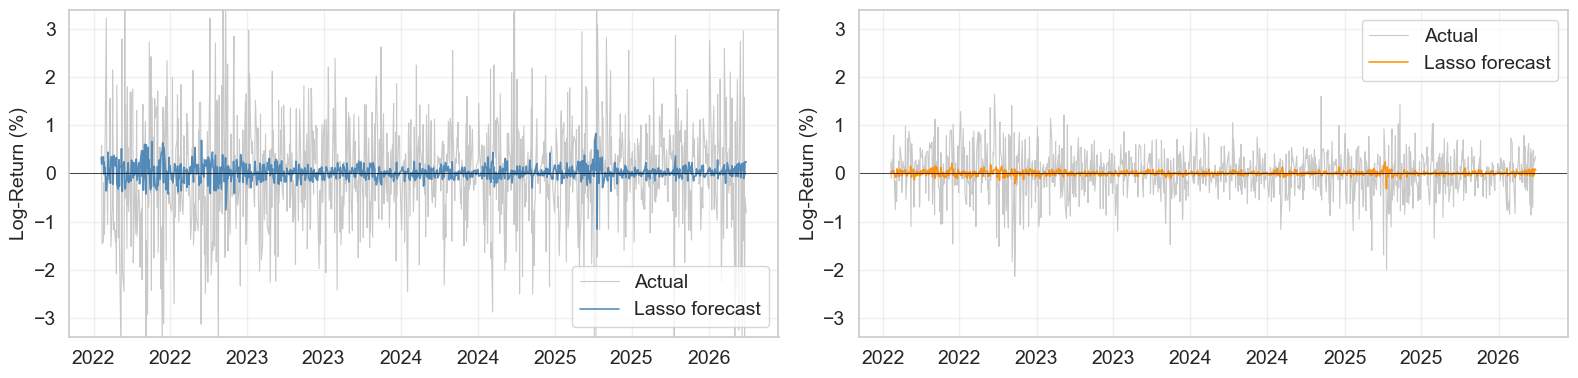

Fig 10 saved.


In [12]:
# Align both lasso series to their own test period
lasso_eem_actual = lasso_eem['actual']
lasso_eem_pred   = lasso_eem['predicted']
lasso_dxy_actual = lasso_dxy['actual']
lasso_dxy_pred   = lasso_dxy['predicted']

all_vals = np.concatenate([
    lasso_eem_actual.values, lasso_dxy_actual.values
])
y_lim = np.percentile(np.abs(all_vals), 99) * 100 * 1.1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

for ax, actual, pred, color, name in [
    (ax1, lasso_eem_actual, lasso_eem_pred, 'steelblue',  'EEM'),
    (ax2, lasso_dxy_actual, lasso_dxy_pred, 'darkorange', 'DXY'),
]:
    ax.plot(actual.index, actual.values * 100,
            color='silver', lw=0.8, alpha=0.85, label='Actual')
    ax.plot(pred.index, pred.values * 100,
            color=color, lw=1.2, alpha=0.9, label='Lasso forecast')
    ax.axhline(0, color='black', lw=0.5)
    rmse = np.sqrt(np.mean((actual.values - pred.values)**2)) * 100
    ax.set_ylabel('Log-Return (%)')
    ax.set_ylim(-y_lim, y_lim)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig10_lasso_forecasts.pdf', bbox_inches='tight')
plt.show()
print("Fig 10 saved.")




### Figure 11 — RF Feature Importance: EEM vs DXY

**What it shows:** Top-15 features by Random Forest importance for each asset,
side by side. Features are the same pool (EEM lags + 9 cross-asset returns +
2 vol proxies for EEM; DXY lags + 9 cross-asset returns + 2 vol proxies for DXY),
but importance rankings diverge.

**Thesis use:** Shows which cross-asset signals drive each market. EEM is
expected to be driven by CNY/JPY (EM currency exposure) and copper/oil (commodity
demand). DXY is expected to be driven by EUR/GBP (currency pairs comprising DXY)
and Treasury yields (interest rate differentials). Differences validate using
separate models per asset rather than a joint model.


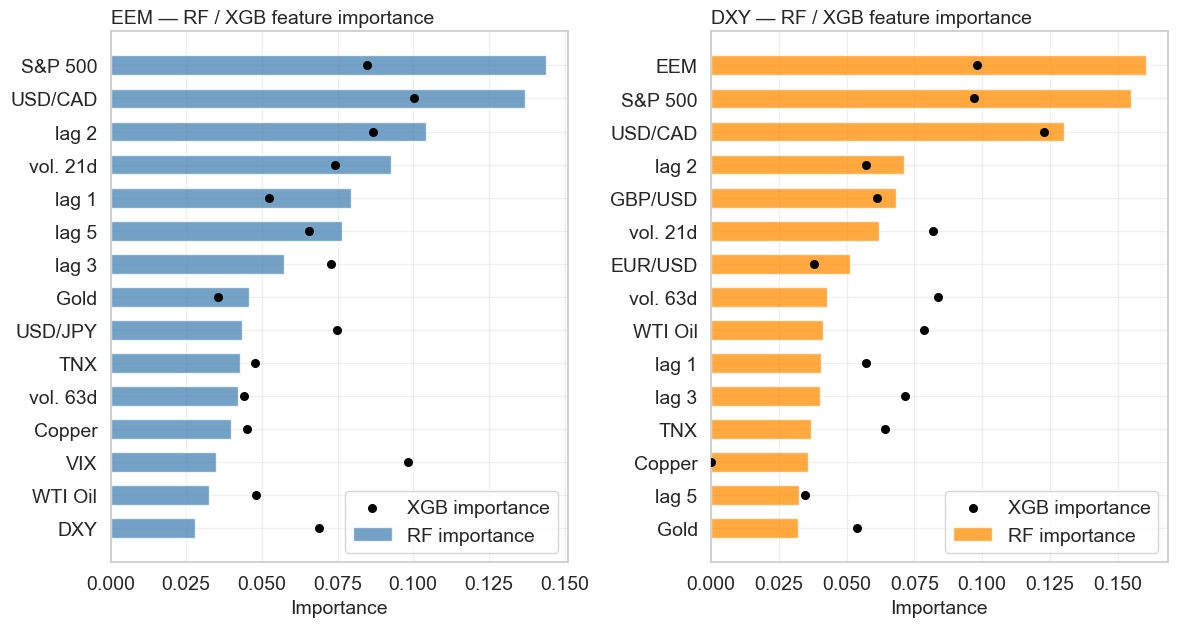

Fig 11 saved.


In [13]:
top_n = 15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6.5))

for ax, rf_imp, gb_imp, color, name in [
    (ax1, eem_rf_imp, eem_gb_imp, 'steelblue',  'EEM'),
    (ax2, dxy_rf_imp, dxy_gb_imp, 'darkorange', 'DXY'),
]:
    own = 'EEM' if name == 'EEM' else 'DXY'
    top = rf_imp.head(top_n).sort_values(ascending=True)
    ax.barh(range(len(top)), top.values,
            color=color, alpha=0.75, edgecolor='white', height=0.6,
            label='RF importance')
    gb_vals = gb_imp.reindex(top.index).fillna(0).loc[top.index]
    ax.scatter(gb_vals.values, range(len(top)),
               color='black', s=30, zorder=5, label='XGB importance')

    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([thesis_feature_label(str(i), own_target=own) for i in top.index])
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} — RF / XGB feature importance', loc='left')
    ax.legend()

plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig11_feature_importance.pdf', bbox_inches='tight')
plt.show()
print("Fig 11 saved.")





### Figure 12 — Pearson correlation matrix (2 targets + 10 exogenous returns)

**What it shows:** **12×12** correlation matrix: **EEM** and **DXY** (DX-Y.NYB) daily log-returns as targets, plus **10** distinct cross-asset **log-return** series — the union of `feature_tickers` from `EMCI_part/config.py` and `DXY_part/config.py` **excluding** `EEM` and `DX-Y.NYB` (those are the targets and are not duplicated as columns). The exogenous set is: `^VIX`, `^TNX`, `CL=F`, `HG=F`, `GC=F`, `^GSPC`, `GBPUSD=X`, `JPY=X`, `EURUSD=X`, `CAD=X` (`CAD=X` appears in both configs; `JPY=X` is EMCI-only; `GBPUSD=X` and `EURUSD=X` are DXY-only). Raw return columns are taken from `eem_dataset_features.csv` / `dxy_dataset_features.csv` (whichever file contains the series); where a ticker appears in both panels, the EMCI copy is used. Rows are restricted to dates in the intersection of both targets’ indices and both feature files; rows with any missing value among the 12 series are dropped. **CSV** is written to `reports/tables/` for direct import into the thesis.

**Axis labels / CSV:** On the heatmap and in the exported CSV, exogenous tickers are renamed to readable labels (VIX, TNX, S&P 500, WTI Oil, Copper, Gold, GBP/USD, USD/JPY, EUR/USD, USD/CAD); targets remain **EEM** and **DXY**. **Colour scale:** The colour bar describes the Pearson correlation range [−1, 1] and how saturation maps to |ρ| for the diverging RdBu_r palette (white at ρ ≈ 0).

**Thesis use:** Compact summary of linear co-movement between the two studied markets and their common macro/FX/commodity drivers.

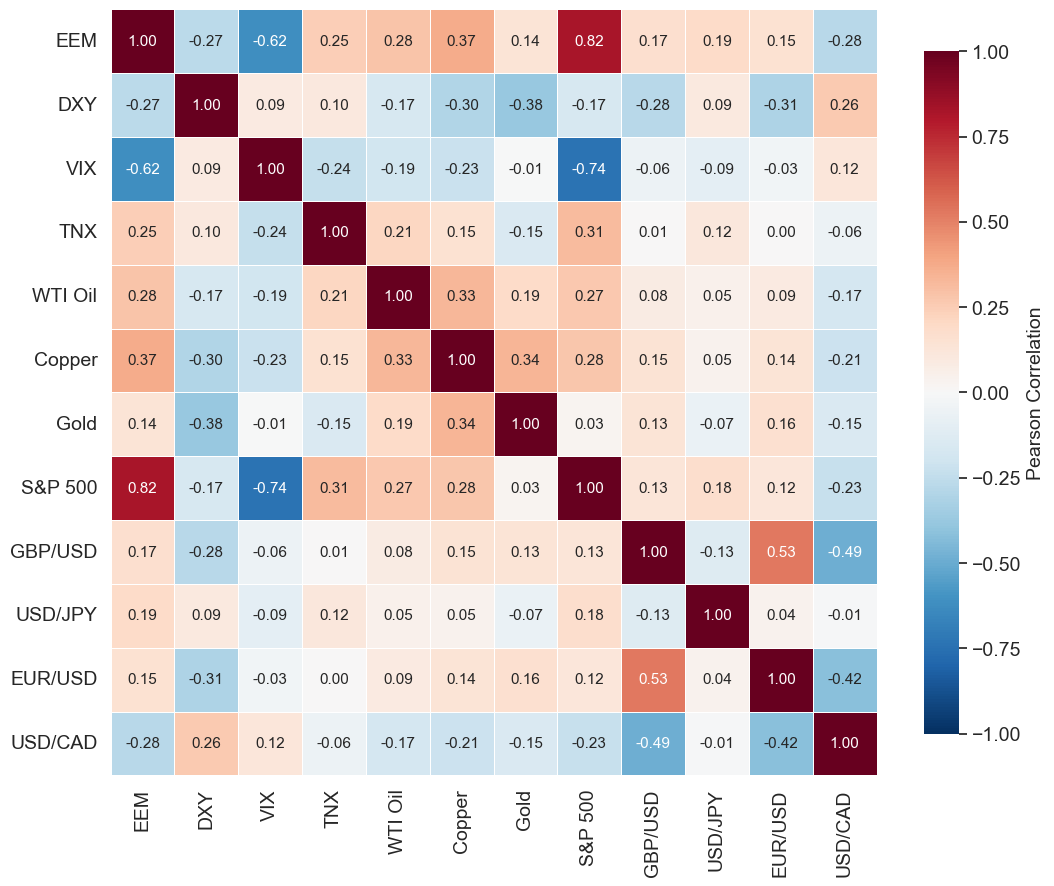

Fig 12 saved.
Correlation CSV -> C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\comp_correlation_matrix_eem_dxy.csv
Panel: 5319 days × 12 variables


In [14]:
# 2 targets + 10 exogenous log-returns: union(EMCI, DXY feature_tickers) minus {EEM, DX-Y.NYB}
# (targets are not duplicated as exogenous columns).
EXOG_10 = [
    "^VIX", "^TNX", "CL=F", "HG=F", "GC=F", "^GSPC", "GBPUSD=X", "JPY=X",
    "EURUSD=X", "CAD=X",
]

# Readable labels on heatmap axes and in CSV (same mapping as imports: FEATURE_TICKER_LABELS).

Xe = pd.read_csv(EMCI / "data/processed/eem_dataset_features.csv", index_col=0, parse_dates=True)
Xd = pd.read_csv(DXY_P / "data/processed/dxy_dataset_features.csv", index_col=0, parse_dates=True)

idx = eem_c.index.intersection(dxy_c.index).intersection(Xe.index).intersection(Xd.index)
Z = pd.DataFrame(
    {
        "EEM": eem_c.loc[idx],
        "DXY": dxy_c.loc[idx],
    }
)
for t in EXOG_10:
    if t in Xe.columns and t in Xd.columns:
        Z[t] = Xe.loc[idx, t]
    elif t in Xe.columns:
        Z[t] = Xe.loc[idx, t]
    elif t in Xd.columns:
        Z[t] = Xd.loc[idx, t]
    else:
        raise KeyError(f"Ticker {t!r} missing from both feature panels")

Z = Z.dropna(how="any")
Z = Z.rename(columns=lambda c: FEATURE_TICKER_LABELS.get(c, c))
corr_full = Z.corr()

TABDIR = ROOT / "reports" / "tables"
TABDIR.mkdir(parents=True, exist_ok=True)
corr_path = TABDIR / "comp_correlation_matrix_eem_dxy.csv"
corr_full.to_csv(corr_path)

fig, ax = plt.subplots(figsize=(11, 9.5))
sns.heatmap(
    corr_full,
    annot=True,
    annot_kws={"fontsize": 11, "fontweight": "normal"},
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={
        "shrink": 0.82,
        "label": (
            "Pearson Correlation"
        ),
    },
)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTDIR / "comp_fig12_correlation_matrix.pdf", bbox_inches="tight")
plt.show()
print("Fig 12 saved.")
print("Correlation CSV ->", corr_path.resolve())
print(f"Panel: {len(Z)} days × {Z.shape[1]} variables")




### Figure 14 — Return distribution boxplots (12 series)

**What it shows:** Side-by-side **boxplots** of daily **log-returns (%)** for **EEM**, **DXY**, and the **10** union exogenous tickers — the **same** aligned panel `Z` as **Figure 12** (intersection of dates, `dropna` on all 12 columns). Useful for comparing dispersion, asymmetry, and **tail outliers** across assets.

**Source:** author's own calculations.


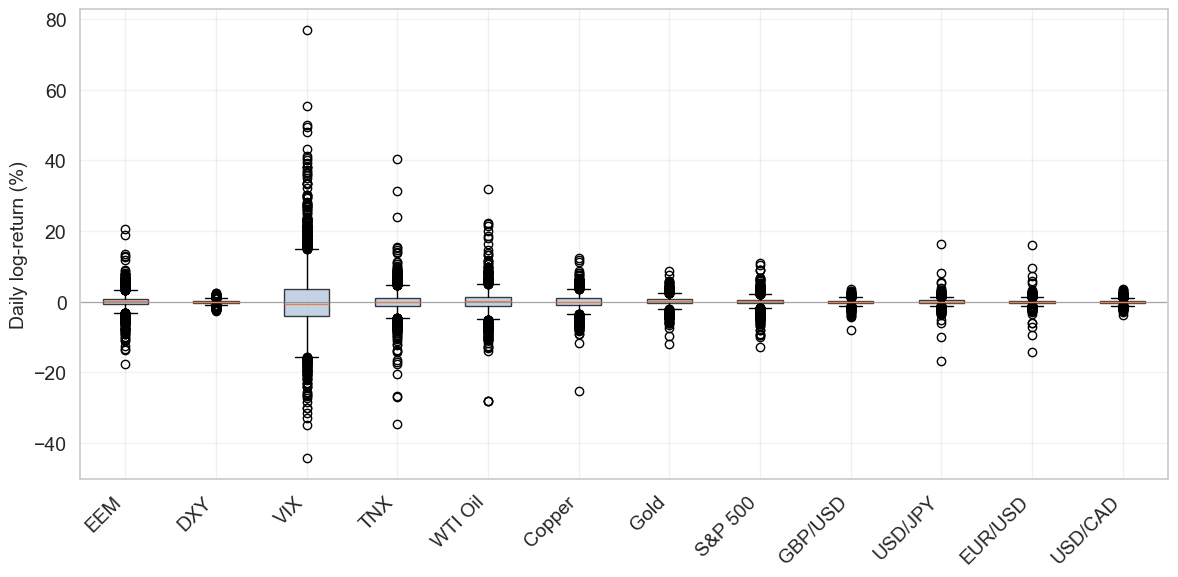

Fig 14 saved.


In [15]:
# Figure 14 — requires Z from the Figure 12 cell above
ret_pct = Z * 100
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(
    [ret_pct[c].values for c in ret_pct.columns],
    patch_artist=True,
    showfliers=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
    patch.set_alpha(0.75)
ax.set_xticklabels(ret_pct.columns, rotation=45, ha="right")
ax.set_ylabel("Daily log-return (%)")
ax.axhline(0.0, color="gray", lw=0.9, alpha=0.65)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTDIR / "comp_fig14_boxplots_all_assets.pdf", bbox_inches="tight")
plt.show()
print("Fig 14 saved.")




### Figure 13 — PACF of EEM and DXY log-returns (40 lags)

**What it shows:** Partial autocorrelation function for **raw** daily log-returns of each asset (lags 1–40), with 95% confidence bands. Complements **Figure 9** (ACF): PACF isolates direct lag‑k dependence after removing intermediate lags.

**Thesis use:** Informs low-order AR structure and contrasts short-memory behaviour of EM equities vs the dollar proxy.

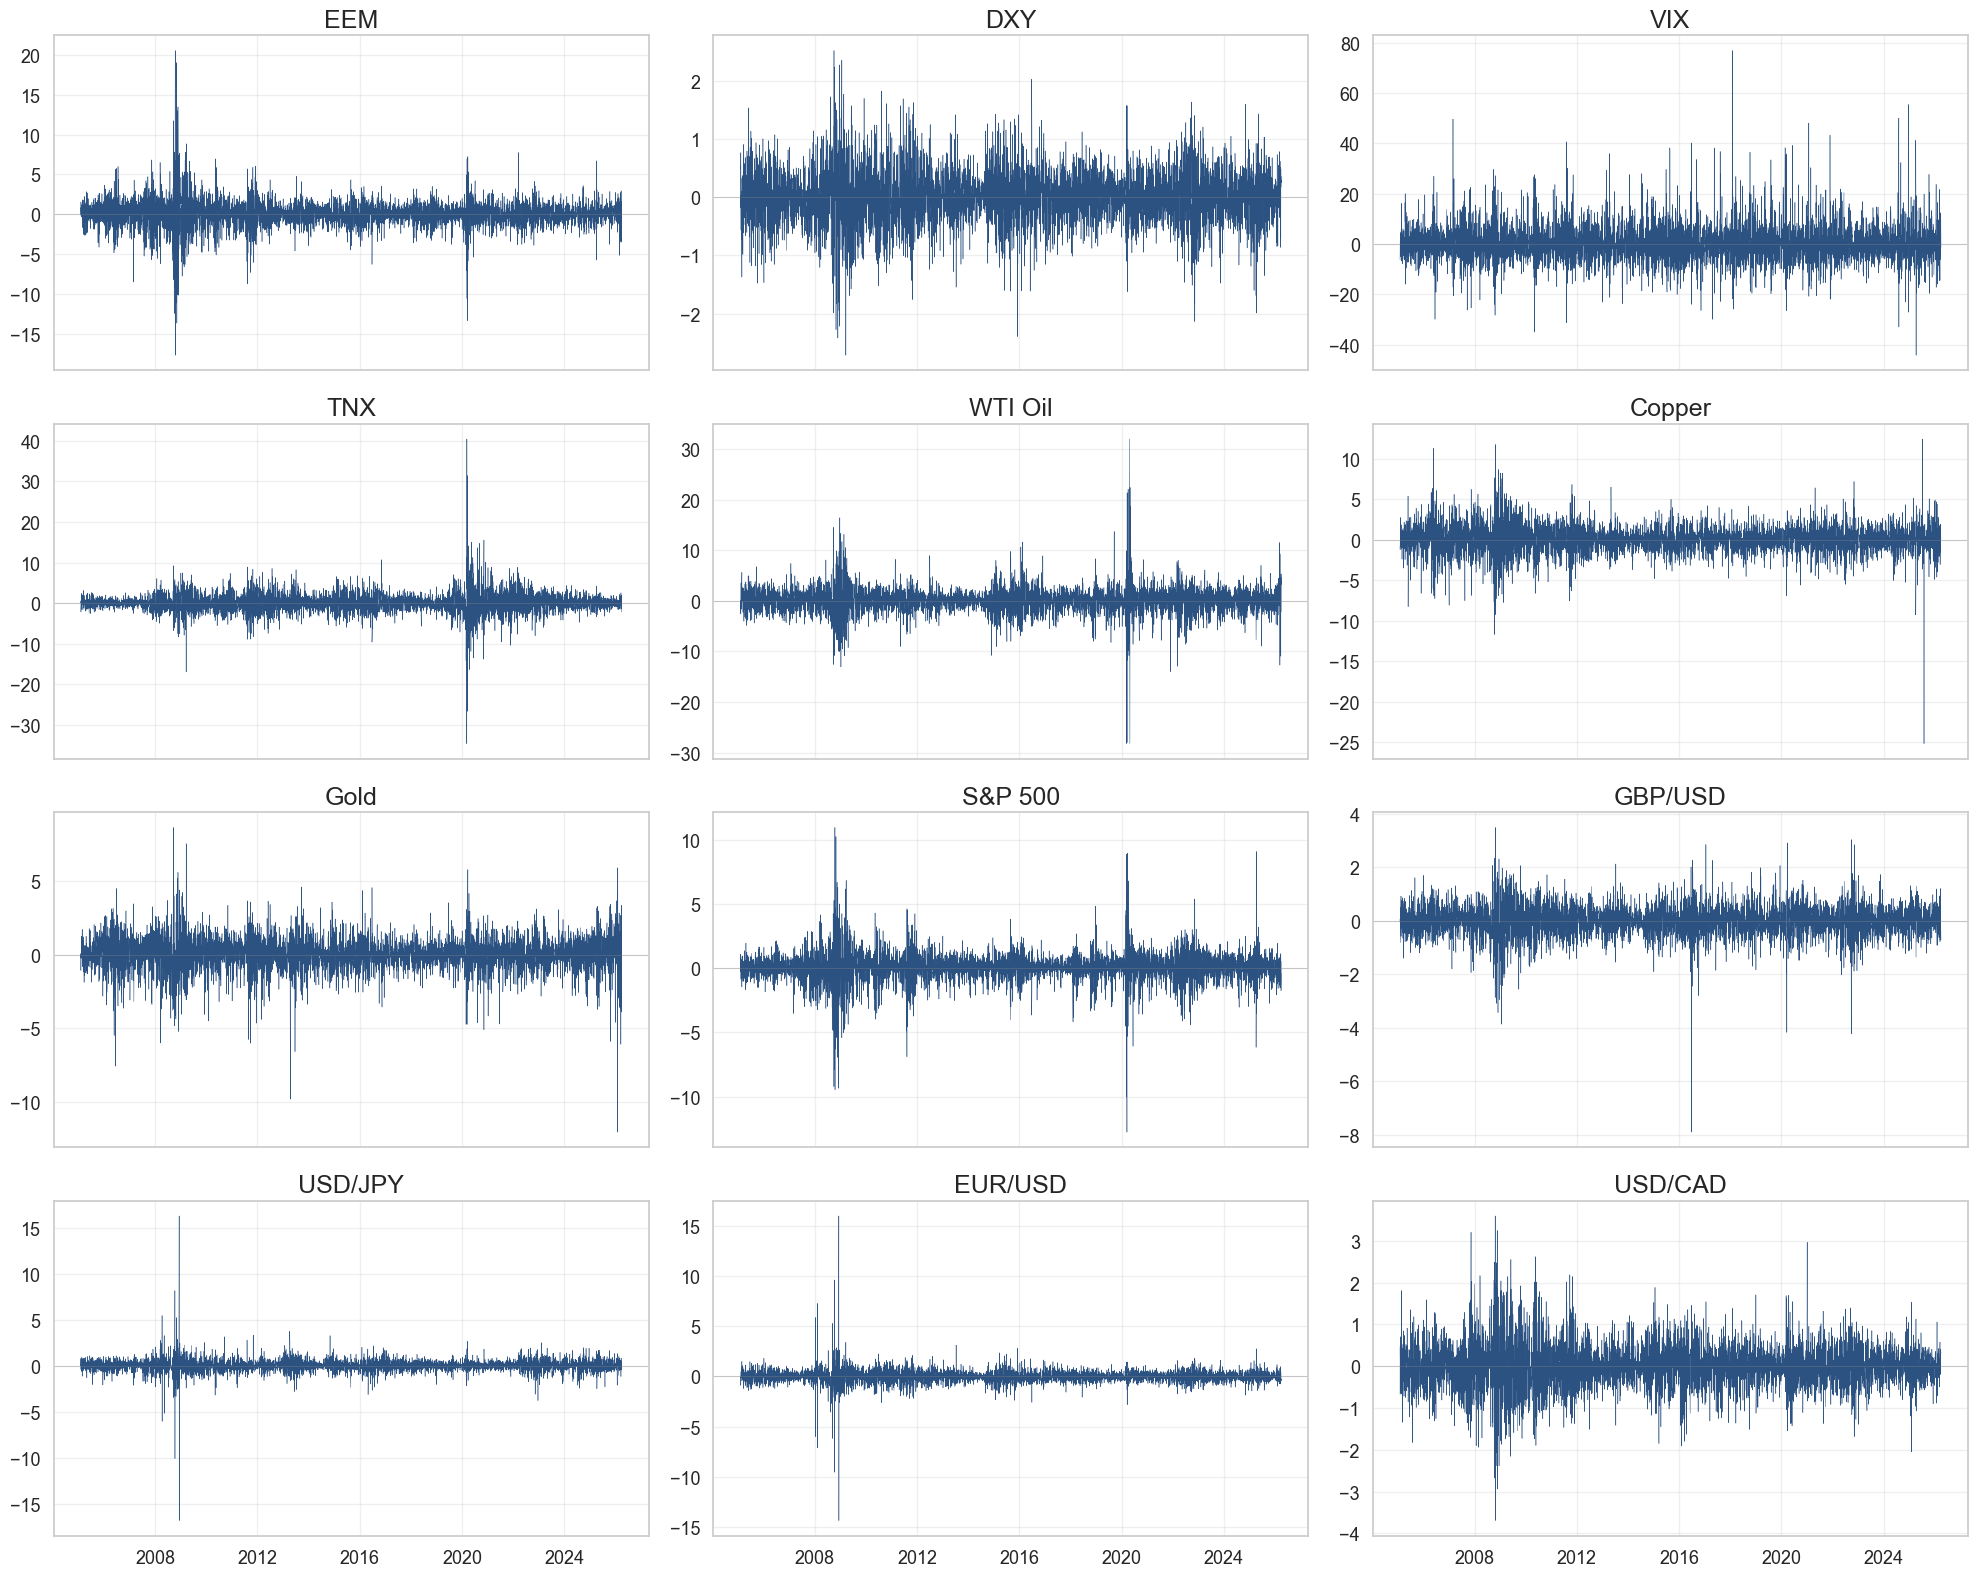

Fig 15 saved.


In [16]:
# Figure 15 — small multiples (same Z as Figure 12)
import math

cols = list(Z.columns)
n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for i, col in enumerate(cols):
    ax = axes[i]
    ax.plot(Z.index, Z[col] * 100, lw=0.35, color="#2c5282")
    ax.set_title(col, size=18)
    ax.axhline(0.0, color="gray", lw=0.5, alpha=0.55)
    ax.tick_params(axis="both", labelsize=13)
for j in range(n, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig(OUTDIR / "comp_fig15_small_multiples_returns.pdf", bbox_inches="tight")
plt.show()
print("Fig 15 saved.")

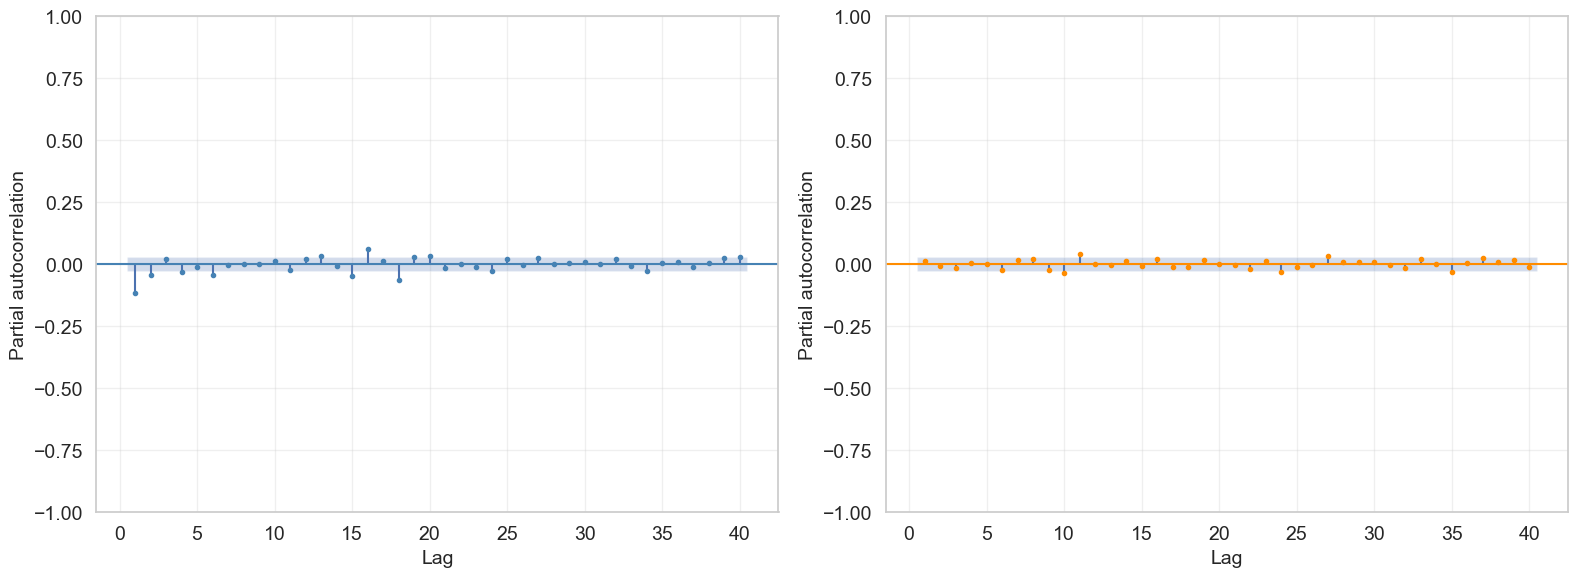

Fig 13 saved.
All 15 comparison figures -> C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, ret, color, name in [
    (ax1, eem_c, "steelblue", "EEM"),
    (ax2, dxy_c, "darkorange", "DXY"),
]:
    plot_pacf(
        ret.values,
        lags=40,
        ax=ax,
        method="ywm",
        alpha=0.05,
        title="",
        zero=False,
        color=color,
        markersize=3,
    )
    ax.set_xlabel("Lag")
    ax.set_ylabel("Partial autocorrelation")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTDIR / "comp_fig13_pacf.pdf", bbox_inches="tight")
plt.show()
print("Fig 13 saved.")
print("All 15 comparison figures ->", OUTDIR.resolve())


### Figure 16 — Two-step GARCH(1,1): standardized residuals (EEM & DXY)

**Purpose:** One compact **2×2** figure for the thesis showing that **Student‑t GARCH on ARIMA residuals** behaves sensibly on **both** assets (same procedure as Laptop 2 / `TwoStepARIMAGARCHModel`).

| Panel | Content |
|-------|--------|
| Top row | **Q–Q plot** of standardized GARCH residuals vs **Student‑t** with df = \(\hat\nu\) from the fitted GARCH step |
| Bottom row | **ACF** of **squared** standardized residuals (no strong serial correlation ⇒ second-moment dynamics largely captured) |

**In-sample:** first **80%** of each aligned return series (same rule as model notebooks). **Mean:** `auto_arima` + SARIMAX (AIC); **variance:** GARCH(1,1) with **t** innovations on ARIMA residuals. Formal **LRT** (GARCH vs constant variance) is reported in Laptop 2 — this figure is **illustrative** residual evidence.


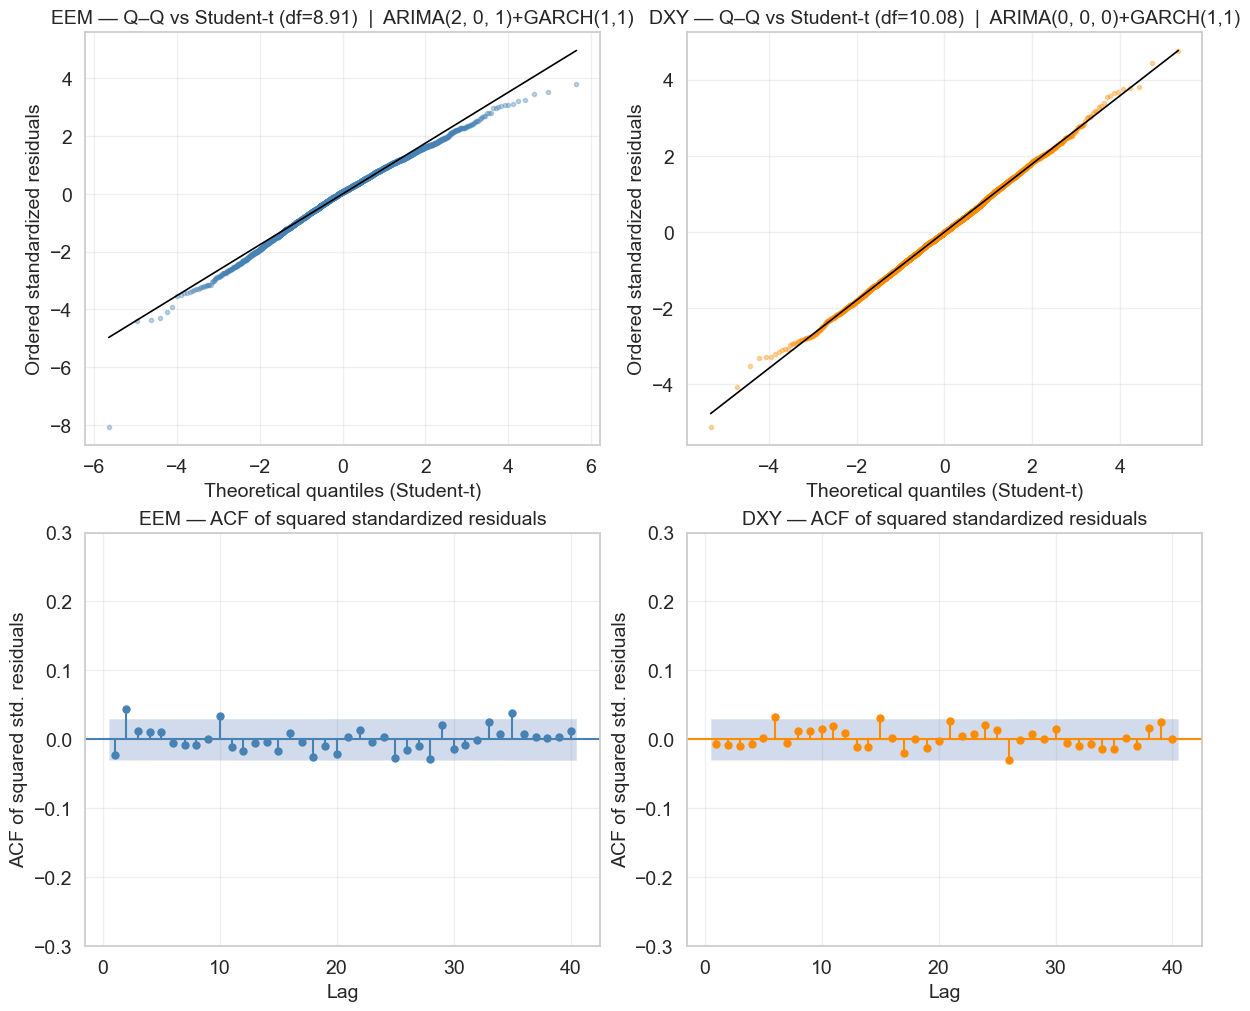

Fig 16 saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures\comp_fig16_garch_twostep_std_resid_2x2.pdf


In [25]:
# --- Fig 16: 2×2 — Student-t Q-Q + ACF(z²) for two-step GARCH (EEM & DXY) ---
import sys

_dxy_root = ROOT / "DXY_part"
if str(_dxy_root.resolve()) not in sys.path:
    sys.path.insert(0, str(_dxy_root.resolve()))

from scipy import stats as _sp_stats_f16
from statsmodels.graphics.tsaplots import plot_acf as _plot_acf_f16
from src.models.twostep_model import TwoStepARIMAGARCHModel as _TwoStepF16


def _fit_garch_std_resid_f16(y_series: pd.Series):
    """In-sample two-step AIC; return standardized GARCH residuals and fitted nu."""
    y_clean = y_series.dropna().copy()
    train_n = int(len(y_clean) * 0.8)
    y_tr = y_clean.iloc[:train_n]
    m = _TwoStepF16(max_p=5, max_q=5, max_d=1, dist="t", information_criterion="aic")
    m.fit(y_tr)
    z = m.std_resid.dropna()
    nu = float(m._garch_result.params.get("nu", 8.0))
    return z, nu, m.order


def _qq_t_f16(ax, z: pd.Series, nu: float, color: str, title: str):
    x = np.asarray(z.values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 20:
        ax.text(0.5, 0.5, "insufficient data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    _sp_stats_f16.probplot(x, dist=_sp_stats_f16.t, sparams=(nu,), plot=ax)
    ax.get_lines()[0].set_markerfacecolor(color)
    ax.get_lines()[0].set_markeredgecolor(color)
    ax.get_lines()[0].set_markersize(3)
    ax.get_lines()[0].set_alpha(0.35)
    if len(ax.get_lines()) > 1:
        ax.get_lines()[1].set_color("black")
        ax.get_lines()[1].set_linewidth(1.2)
    ax.set_title(title)
    ax.set_xlabel("Theoretical quantiles (Student-t)")
    ax.set_ylabel("Ordered standardized residuals")


def _acf_sq_f16(ax, z: pd.Series, color: str, title: str):
    w = (z ** 2).dropna()
    if w.size < 30:
        ax.text(0.5, 0.5, "insufficient data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    _plot_acf_f16(
        w.values,
        lags=40,
        ax=ax,
        alpha=0.05,
        title="",
        color=color,
        vlines_kwargs={"colors": color},
        zero=False
    )
    ax.set_title(title)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF of squared std. residuals")


z_eem, nu_eem, ord_eem = _fit_garch_std_resid_f16(eem_c)
z_dxy, nu_dxy, ord_dxy = _fit_garch_std_resid_f16(dxy_c)

fig16, axes16 = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
_qq_t_f16(
    axes16[0, 0], z_eem, nu_eem, "steelblue",
    f"EEM — Q–Q vs Student-t (df={nu_eem:.2f})  |  ARIMA{ord_eem}+GARCH(1,1)",
)
_qq_t_f16(
    axes16[0, 1], z_dxy, nu_dxy, "darkorange",
    f"DXY — Q–Q vs Student-t (df={nu_dxy:.2f})  |  ARIMA{ord_dxy}+GARCH(1,1)",
)
_acf_sq_f16(axes16[1, 0], z_eem, "steelblue", "EEM — ACF of squared standardized residuals")
_acf_sq_f16(axes16[1, 1], z_dxy, "darkorange", "DXY — ACF of squared standardized residuals")

axes16[1, 0].set_ylim(-0.3, 0.3)
axes16[1, 1].set_ylim(-0.3, 0.3)

plt.savefig(OUTDIR / "comp_fig16_garch_twostep_std_resid_2x2.pdf", bbox_inches="tight")
plt.show()
print("Fig 16 saved:", (OUTDIR / "comp_fig16_garch_twostep_std_resid_2x2.pdf").resolve())


### Figure 17 — Two-step GARCH: returns & conditional volatility (EEM & DXY)

**Purpose:** Same visual idea as **Laptop 2 / `fig1_garch_volatility.pdf`**: daily **log-returns** (%) and **annualized** GARCH(1,1) **conditional volatility** on the **in-sample training window** (first **80%** of each series), for **EEM** then **DXY** in one figure.

**Model:** `TwoStepARIMAGARCHModel` (AIC `auto_arima` + SARIMAX, then Student‑t GARCH on residuals). Orange / green bands mark the **2008–09** and **2020** stress windows (as in Notebook 2).


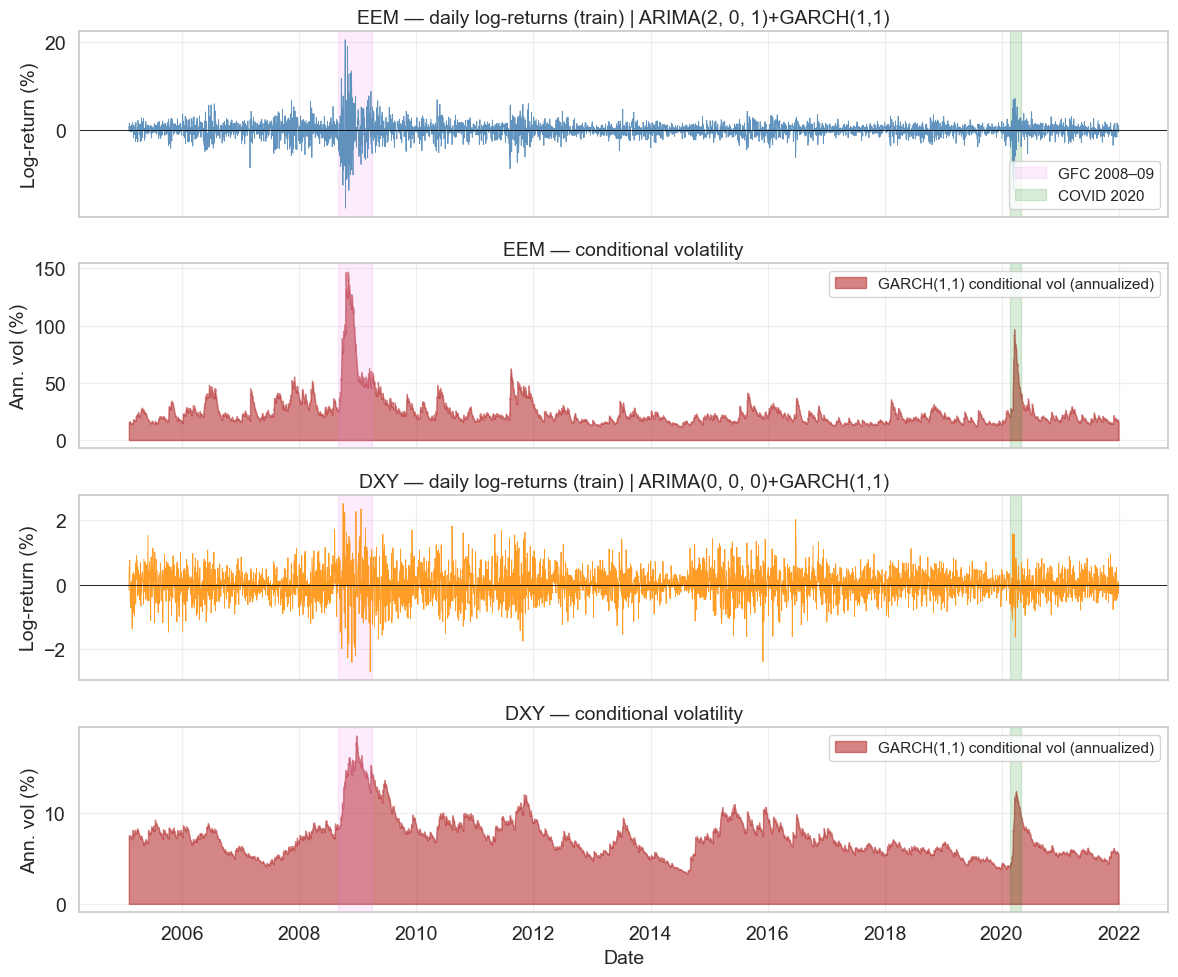

Fig 17 saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures\comp_fig17_garch_twostep_returns_vol_eem_dxy.pdf


In [ ]:
# --- Fig 17: returns + annualized GARCH conditional vol (EEM & DXY, two-step) ---
import sys

_dxy_r17 = ROOT / "DXY_part"
if str(_dxy_r17.resolve()) not in sys.path:
    sys.path.insert(0, str(_dxy_r17.resolve()))

from src.models.twostep_model import TwoStepARIMAGARCHModel as _TwoStepF17


def _train_garch_vol_f17(y_series: pd.Series):
    """80% train, two-step AIC; returns y_train, vol index, annualized sigma, ARIMA order."""
    y_clean = y_series.dropna().copy()
    train_n = int(len(y_clean) * 0.8)
    y_tr = y_clean.iloc[:train_n]
    m = _TwoStepF17(max_p=5, max_q=5, max_d=1, dist="t", information_criterion="aic")
    m.fit(y_tr)
    cond = m._garch_result.conditional_volatility / 100.0
    ann = cond * np.sqrt(252.0)
    idx_v = y_tr.index[-len(cond) :]
    return y_tr, idx_v, ann, m.order


y_eem_tr, idx_eem_v, ann_eem, ord_eem = _train_garch_vol_f17(eem_c)
y_dxy_tr, idx_dxy_v, ann_dxy, ord_dxy = _train_garch_vol_f17(dxy_c)

fig17, axes17 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes17[0].plot(y_eem_tr.index, y_eem_tr.values * 100, color="steelblue", lw=0.6, alpha=0.85)
axes17[0].axhline(0, color="black", lw=0.6)
axes17[0].set_ylabel("Log-return (%)")
axes17[0].set_title(f"EEM — daily log-returns (train) | ARIMA{ord_eem}+GARCH(1,1)")

axes17[1].fill_between(
    idx_eem_v,
    ann_eem * 100,
    alpha=0.55,
    color="firebrick",
    label="GARCH(1,1) conditional vol (annualized)",
)
axes17[1].set_ylabel("Ann. vol (%)")
axes17[1].set_title("EEM — conditional volatility")
axes17[1].legend(loc="upper right", fontsize=11)

axes17[2].plot(y_dxy_tr.index, y_dxy_tr.values * 100, color="darkorange", lw=0.6, alpha=0.85)
axes17[2].axhline(0, color="black", lw=0.6)
axes17[2].set_ylabel("Log-return (%)")
axes17[2].set_title(f"DXY — daily log-returns (train) | ARIMA{ord_dxy}+GARCH(1,1)")

axes17[3].fill_between(
    idx_dxy_v,
    ann_dxy * 100,
    alpha=0.55,
    color="firebrick",
    label="GARCH(1,1) conditional vol (annualized)",
)
axes17[3].set_ylabel("Ann. vol (%)")
axes17[3].set_xlabel("Date")
axes17[3].set_title("DXY — conditional volatility")
axes17[3].legend(loc="upper right", fontsize=11)

for ax in axes17:
    ax.axvspan(
        pd.Timestamp("2008-09-01"),
        pd.Timestamp("2009-03-31"),
        alpha=0.15,
        color="violet",
        label="GFC 2008–09",
    )
    ax.axvspan(
        pd.Timestamp("2020-02-20"),
        pd.Timestamp("2020-04-30"),
        alpha=0.15,
        color="green",
        label="COVID 2020",
    )

axes17[0].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.savefig(OUTDIR / "comp_fig17_garch_twostep_returns_vol_eem_dxy.pdf", bbox_inches="tight")
plt.show()
print("Fig 17 saved:", (OUTDIR / "comp_fig17_garch_twostep_returns_vol_eem_dxy.pdf").resolve())


### Figure 18 — Ridge and Lasso: absolute coefficients (four panels)

**What it shows:** A **2×2** grid of horizontal bar charts — **EEM** (top row) and **DXY** (bottom row); **Ridge** (left column) and **Lasso** (right column). Each panel ranks the top **15** features by **that model’s** absolute coefficient on **standardized** inputs (notebooks 02–03). No overlay markers, so **Lasso zeros** do not appear as dots on the Ridge axis.

**Thesis use:** Clean separation of **L2 shrinkage** (Ridge) and **L1 selection** (Lasso) for each target, with a shared **x**-scale within each asset row for comparability.


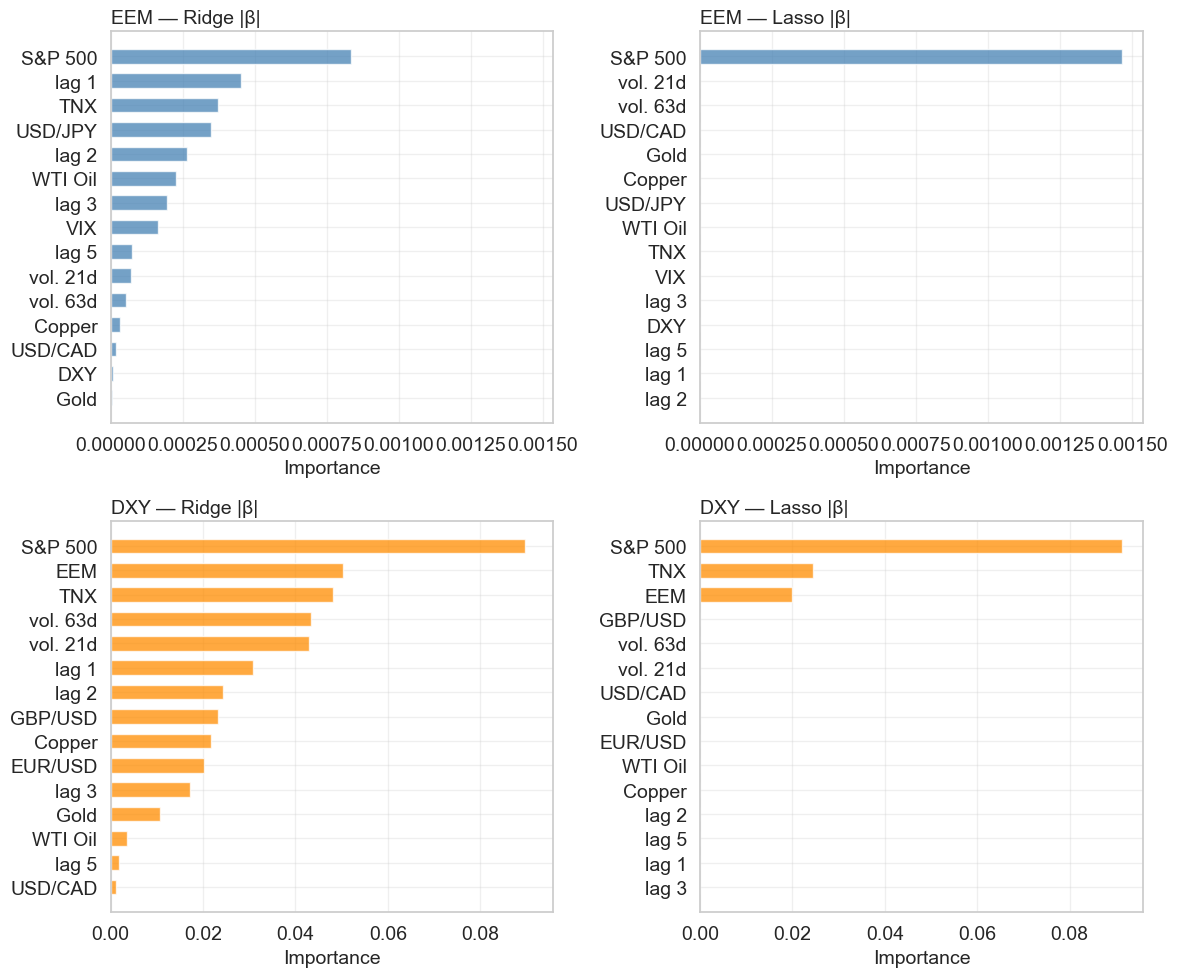

Fig 18 saved.


In [20]:
top_n = 15

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex='row')

panels = [
    (axes[0, 0], eem_ridge_abs,  'steelblue',  'EEM — Ridge |β|', 'EEM'),
    (axes[0, 1], eem_lasso_abs,  'steelblue',  'EEM — Lasso |β|', 'EEM'),
    (axes[1, 0], dxy_ridge_abs,  'darkorange', 'DXY — Ridge |β|', 'DXY'),
    (axes[1, 1], dxy_lasso_abs,  'darkorange', 'DXY — Lasso |β|', 'DXY'),
]

for ax, imp_ser, color, title, own in panels:
    top = imp_ser.head(top_n).sort_values(ascending=True)
    ax.barh(
        range(len(top)),
        top.values,
        color=color,
        alpha=0.75,
        edgecolor='white',
        height=0.6,
    )
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([thesis_feature_label(str(i), own_target=own) for i in top.index])
    ax.set_xlabel('Importance')
    ax.set_title(title, loc='left')

plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig18_ridge_lasso_importance.pdf', bbox_inches='tight')
plt.show()
print('Fig 18 saved.')


### Figure 19 - Rolling OOS Forecasts vs Actual Returns — two-step ARIMA+GARCH, exog-variable models, and ML (stacked EEM / DXY)

**What it shows:** Rolling **one-step-ahead** OOS forecasts: two-step univariate **ARIMA+GARCH**; then all specifications that use **exogenous** information — two-step **ARIMAX+GARCH**, **joint ARX+GARCH**, **Ridge**, **Lasso**, **Random Forest**, **Gradient Boosting**, and **SVR** — overlaid on the realised returns. **EEM** is on the top panel, **DXY** on the bottom (shared y-scale, 99th-percentile absolute-value heuristic).

**How to read:** Grey line is actual log-returns; each coloured line is one model's OOS prediction. The spread between coloured lines shows how much the modelling choice matters; the fact that all of them sit near zero most of the time is itself the main finding — exogenous information only nudges the forecast a little.

**Requires:** `arimax_garch_predictions.csv`, `joint_arx_predictions.csv`, `ridge_predictions.csv`, `lasso_predictions.csv` (from NB02) and `rf_predictions.csv`, `gb_predictions.csv`, `svr_predictions.csv` (from NB03) in each asset's `data/processed/`. Missing files are skipped silently.

**Thesis use:** Printable single-column variant of Figure 10.


EEM forecasts available: ['ARIMAX+GARCH', 'Joint ARX+GARCH', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boost', 'SVR']
DXY forecasts available: ['ARIMAX+GARCH', 'Joint ARX+GARCH', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boost', 'SVR']


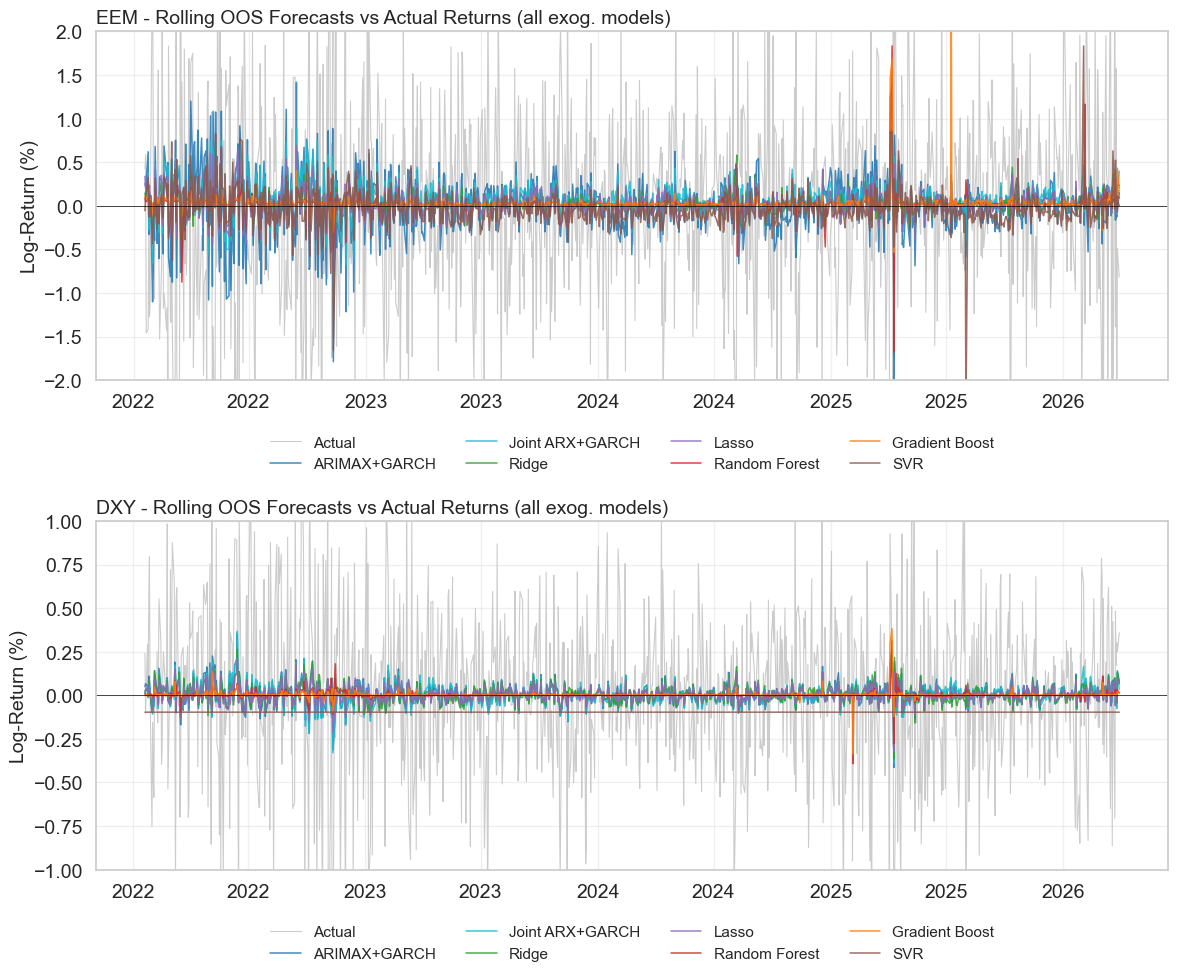

Fig 19 saved.


In [28]:
# --- Figure 19: Rolling OOS Forecasts vs Actual Returns (all models with exogenous regressors) ---
# Two stacked panels: EEM on top, DXY on bottom.
# Shows every model that uses cross-asset exogenous features:
#   ARIMA+GARCH, two-step ARIMAX+GARCH, joint ARX+GARCH, Ridge, Lasso, Random Forest, Gradient Boosting, SVR.
# Each model is loaded from its rolling-OOS predictions CSV (produced by NB02 / NB03).
# Missing CSVs are skipped gracefully so the figure still renders with whatever is available.

EXOG_MODELS = [
    ('ARIMAX+GARCH', 'arimax_garch_predictions.csv', '#1f77b4'),
    ('Joint ARX+GARCH', 'joint_arx_predictions.csv',   '#17becf'),
    ('Ridge',          'ridge_predictions.csv',        '#2ca02c'),
    ('Lasso',          'lasso_predictions.csv',        '#9467bd'),
    ('Random Forest',  'rf_predictions.csv',           '#d62728'),
    ('Gradient Boost', 'gb_predictions.csv',           '#ff7f0e'),
    ('SVR',            'svr_predictions.csv',          '#8c564b'),
]

def _load_preds(base, fname):
    p = base / 'data' / 'processed' / fname
    if not p.exists():
        return None
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    return df

eem_forecasts, dxy_forecasts = {}, {}
eem_actual = dxy_actual = None
for label, fname, color in EXOG_MODELS:
    df_e = _load_preds(EMCI,  fname)
    df_d = _load_preds(DXY_P, fname)
    if df_e is not None:
        eem_forecasts[label] = (df_e['predicted'], color)
        if eem_actual is None:
            eem_actual = df_e['actual']
    if df_d is not None:
        dxy_forecasts[label] = (df_d['predicted'], color)
        if dxy_actual is None:
            dxy_actual = df_d['actual']

print('EEM forecasts available:', list(eem_forecasts))
print('DXY forecasts available:', list(dxy_forecasts))

if eem_actual is None or dxy_actual is None:
    raise RuntimeError('No prediction CSVs found. Re-run NB02 / NB03 first.')

# Fixed y-limits (Log-Return %): wider for EEM, tighter for DXY
_Y_LIMS_F19 = {'EEM': (-2.0, 2.0), 'DXY': (-1.0, 1.0)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

for ax, actual, forecasts, name in [
    (ax1, eem_actual, eem_forecasts, 'EEM'),
    (ax2, dxy_actual, dxy_forecasts, 'DXY'),
]:
    ax.plot(actual.index, actual.values * 100,
            color='silver', lw=0.8, alpha=0.8, label='Actual', zorder=1)
    for label, (pred, color) in forecasts.items():
        ax.plot(pred.index, pred.values * 100,
                color=color, lw=1.1, alpha=0.85, label=label, zorder=2)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_ylabel('Log-Return (%)')
    ax.set_ylim(*_Y_LIMS_F19[name])
    ax.set_title(f'{name} - Rolling OOS Forecasts vs Actual Returns (all exog. models)', loc='left')
    ax.legend(ncol=4, loc='upper center', fontsize=11, frameon=False,
              bbox_to_anchor=(0.5, -0.12))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig19_rolling_oos_stacked.pdf', bbox_inches='tight')
plt.show()
print('Fig 19 saved.')


### Figure 20 - Block Permutation Test: Distribution of Permuted RMSEs vs Real RMSE (stacked EEM / DXY)

**What it shows:** For each ML model (Random Forest, Gradient Boosting, SVR) we compare the **real** out-of-sample RMSE (red vertical line) against the distribution of RMSEs obtained by refitting the same model on **200 block-permuted** copies of the training target (21-day blocks preserve short-run autocorrelation and volatility clustering). **EEM** panels are on the **top row**, **DXY** panels on the **bottom row**. Each subplot title reports the empirical p-value = P(permuted RMSE ≤ real RMSE).

**How to read:** If the red line sits in the **left tail** of the blue distribution (p ≤ 0.05) the model meaningfully beats block-shuffled noise. If the red line sits inside the bulk of the histogram (p ≻ 0.05, as we see here), then fitting on the real return sequence gives essentially the same OOS accuracy as fitting on shuffled blocks — i.e. the model is learning noise, not exploitable signal. This is the single strongest piece of EMH-consistent evidence in the thesis.

**Requires:** `perm_rmses_dict.pkl` in each asset's `data/processed/` (produced by the permutation-test cell at the end of NB03). The cell below skips gracefully if a file is missing.

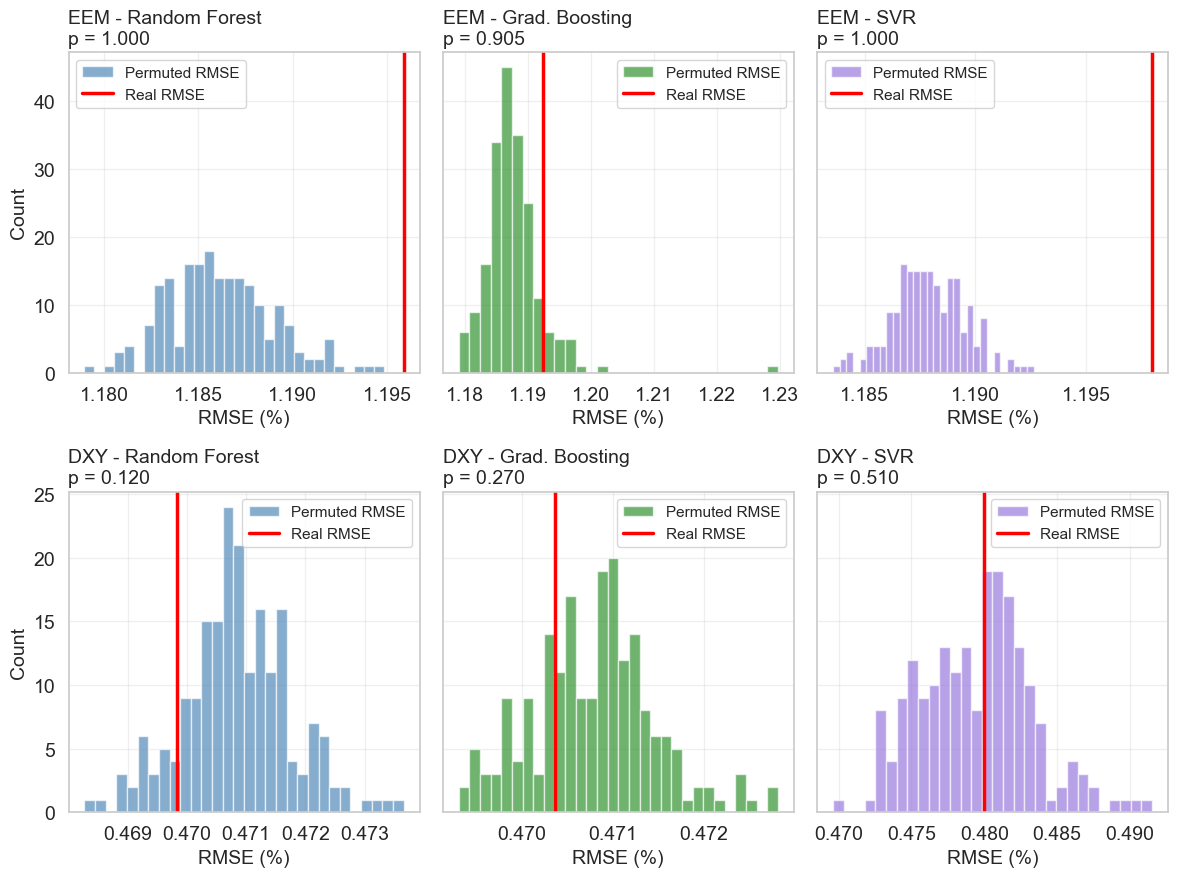

Fig 20 saved.


In [22]:
# --- Figure 20: Block Permutation Test - stacked EEM (top) / DXY (bottom) ---
import pickle as _pkl

def _load_perm(base):
    p = base / 'data' / 'processed' / 'perm_rmses_dict.pkl'
    if not p.exists():
        return None
    with open(p, 'rb') as fh:
        return _pkl.load(fh)

perm_eem = _load_perm(EMCI)
perm_dxy = _load_perm(DXY_P)

if perm_eem is None or perm_dxy is None:
    missing = []
    if perm_eem is None: missing.append('EMCI')
    if perm_dxy is None: missing.append('DXY')
    raise RuntimeError(f'perm_rmses_dict.pkl not found for: {missing}. Re-run NB03 permutation-test cell first.')

model_names = list(perm_eem.keys())
n_models    = len(model_names)
perm_colors = ['steelblue', 'forestgreen', 'mediumpurple', 'teal', 'darkorange']

fig, axes = plt.subplots(2, n_models, figsize=(4 * n_models, 9), sharey='row')
if n_models == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for row_idx, (asset_name, perm_dict) in enumerate([('EEM', perm_eem), ('DXY', perm_dxy)]):
    for col_idx, name in enumerate(model_names):
        if name not in perm_dict:
            axes[row_idx, col_idx].set_visible(False)
            continue
        real_rmse, perm_rmses = perm_dict[name]
        perm_arr = np.asarray(perm_rmses, dtype=float)
        p_val = float(np.mean(perm_arr <= real_rmse))
        ax = axes[row_idx, col_idx]
        ax.hist(perm_arr * 100, bins=30, color=perm_colors[col_idx % len(perm_colors)],
                alpha=0.65, edgecolor='white', label='Permuted RMSE')
        ax.axvline(real_rmse * 100, color='red', lw=2.5, linestyle='-',
                   label='Real RMSE')
        ax.set_title(f'{asset_name} - {name}\np = {p_val:.3f}', loc='left')
        ax.set_xlabel('RMSE (%)')
        if col_idx == 0:
            ax.set_ylabel('Count')
        ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig20_block_permutation_stacked.pdf', bbox_inches='tight')
plt.show()
print('Fig 20 saved.')


### Figure 21 — OOS RMSE: all core models (EEM vs DXY)

**What it shows:** Two **stacked** horizontal bar charts (EEM on top, DXY on bottom), each sorted by **descending** out-of-sample RMSE. Models: **ARIMA(0,0,0)**, two-step **ARIMA+GARCH**, **ARIMAX+GARCH**, **joint AR+GARCH**, **joint ARX+GARCH**, **Random Forest**, **Gradient Boosting**, and **SVR** (Ridge/Lasso omitted, as in NB03 bar chart). Short axis labels keep both panels aligned; the exact ARIMA/ARIMAX \((p,d,q)\) orders and joint AR lag \(p\) are in **NB02 / NB03** for each asset.

**Requires:** Rolling OOS prediction CSVs in each asset’s `data/processed/` — the same files as **Figure 19**, plus **`arima000_predictions.csv`**, **`arima_garch_predictions.csv`** (two-step ARIMA+GARCH), and **`joint_ar_predictions.csv`** when **NB02** has been re-run after those exports were added. If `arima000_predictions.csv` is missing, the dashed baseline uses the **demeaned-realized** RMSE \(\sqrt{\mathbb{E}[(y_t-\bar y)^2]}\) on the OOS `actual` column (numerically almost identical to the rolling **ARIMA(0,0,0)** line in practice). If `joint_ar_predictions.csv` or `arima_garch_predictions.csv` is missing, that row is skipped with a console warning.

**Scales:** Each panel uses its **own** x-axis limits (RMSE for EEM is much larger than for DXY), so bar lengths are comparable within a panel, not across panels.

**Thesis use:** Single figure comparing forecast difficulty and relative ranking of methods across **EEM** and **DXY** on a common visual template.

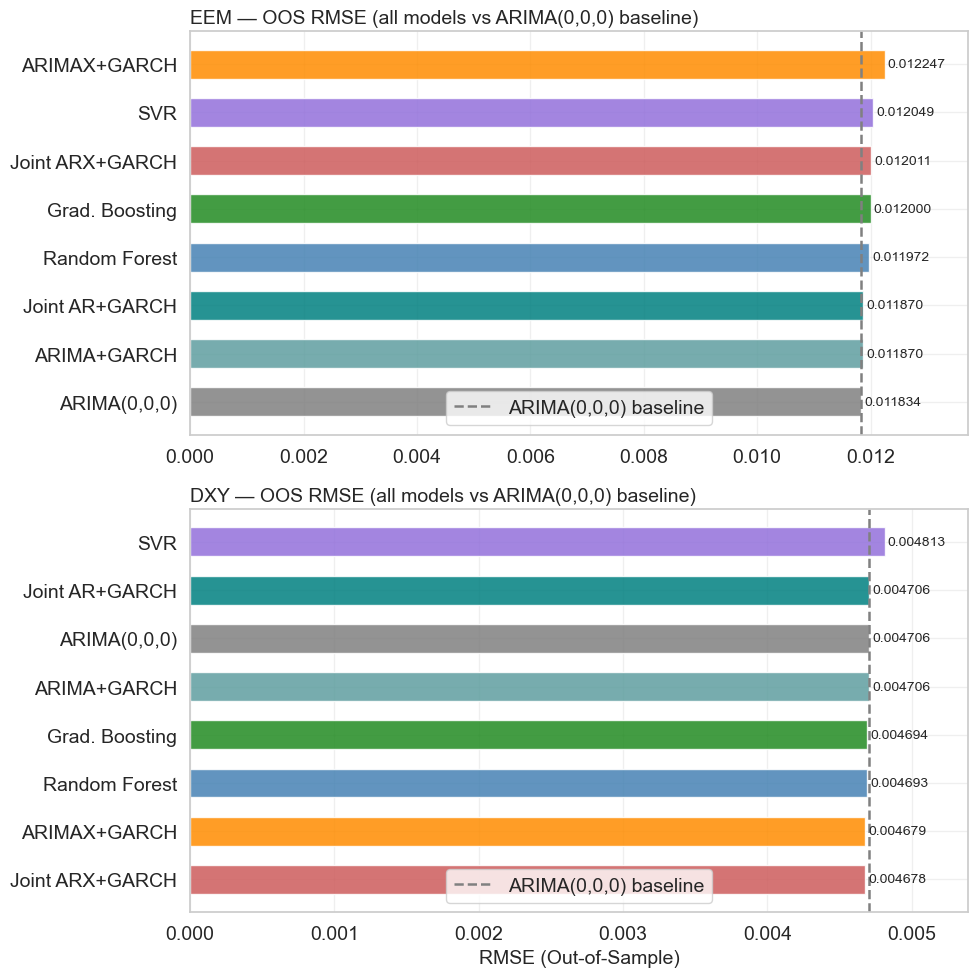

Fig 21 saved.


In [23]:
# --- Figure 21: OOS RMSE — all core models (EEM top / DXY bottom) ---
# Core OOS models: NB02 (ARIMA(0,0,0), two-step ARIMA+GARCH, ARIMAX, joint AR/ARX) + NB03 ML (not Ridge/Lasso).

RMSE_MODEL_ROWS = [
    ('arima000', 'arima000_predictions.csv', 'ARIMA(0,0,0)', 'gray'),
    ('arima_garch', 'arima_garch_predictions.csv', 'ARIMA+GARCH', 'cadetblue'),
    ('arimax', 'arimax_garch_predictions.csv', 'ARIMAX+GARCH', 'darkorange'),
    ('joint_ar', 'joint_ar_predictions.csv', 'Joint AR+GARCH', 'teal'),
    ('joint_arx', 'joint_arx_predictions.csv', 'Joint ARX+GARCH', 'indianred'),
    ('rf', 'rf_predictions.csv', 'Random Forest', 'steelblue'),
    ('gb', 'gb_predictions.csv', 'Grad. Boosting', 'forestgreen'),
    ('svr', 'svr_predictions.csv', 'SVR', 'mediumpurple'),
]


def _read_preds(base, fname):
    p = base / 'data' / 'processed' / fname
    if not p.exists():
        return None
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    if df.empty or not {'actual', 'predicted'}.issubset(df.columns):
        return None
    return df


def _oos_rmse_df(df):
    a = df['actual'].astype(float)
    pr = df['predicted'].astype(float)
    return float(np.sqrt(np.mean((a - pr) ** 2)))


def _fallback_baseline_rmse(df):
    """Demeaned realized RMSE on OOS actuals — close to rolling ARIMA(0,0,0) when μ̂ ≈ ȳ."""
    a = df['actual'].astype(float)
    c = a - a.mean()
    return float(np.sqrt(np.mean(c ** 2)))


def _collect_rmse_map(base):
    rmse = {}
    ref_df = None
    for key, fname, _, _ in RMSE_MODEL_ROWS:
        d = _read_preds(base, fname)
        if d is None:
            if key in ('joint_ar', 'arima_garch'):
                print(f'  [warn] {base.name}: missing {fname} — re-run NB02 save cell.')
            continue
        if ref_df is None:
            ref_df = d
        rmse[key] = _oos_rmse_df(d)
    if ref_df is None:
        return {}
    if 'arima000' not in rmse:
        rmse['arima000'] = _fallback_baseline_rmse(ref_df)
    return rmse


eem_rmse = _collect_rmse_map(EMCI)
dxy_rmse = _collect_rmse_map(DXY_P)

if len(eem_rmse) < 3 or len(dxy_rmse) < 3:
    raise RuntimeError('Too few prediction CSVs for Figure 21. Re-run NB02 / NB03.')


def _plot_rmse_panel(ax, rmse_map, title, *, show_xlabel: bool = True):
    rows = [(k, lab, col) for k, _, lab, col in RMSE_MODEL_ROWS if k in rmse_map]
    rows.sort(key=lambda t: rmse_map[t[0]], reverse=True)
    y = np.arange(len(rows))
    vals = [rmse_map[k] for k, _, _ in rows]
    cols = [c for _, _, c in rows]
    labs = [lab for _, lab, _ in rows]
    ax.barh(y, vals, color=cols, alpha=0.85, edgecolor='white', height=0.6)
    bl = rmse_map.get('arima000')
    if bl is not None:
        ax.axvline(bl, color='gray', linestyle='--', lw=1.8, label='ARIMA(0,0,0) baseline')
        ax.legend(loc='lower center')
    ax.set_yticks(y)
    ax.set_yticklabels(labs)
    ax.invert_yaxis()
    cap = list(vals)
    if bl is not None:
        cap.append(bl)
    xmax = float(max(cap) * 1.12) if cap else 1.0
    ax.set_xlim(0, xmax)
    if show_xlabel:
        ax.set_xlabel('RMSE (Out-of-Sample)')
    ax.set_title(title, loc='left')
    for yi, v in zip(y, vals):
        ax.text(v + xmax * 0.004, yi, f'{v:.6f}', va='center', fontsize=10)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=False)
_plot_rmse_panel(ax1, eem_rmse, 'EEM — OOS RMSE (all models vs ARIMA(0,0,0) baseline)', show_xlabel=False)
_plot_rmse_panel(ax2, dxy_rmse, 'DXY — OOS RMSE (all models vs ARIMA(0,0,0) baseline)', show_xlabel=True)
plt.tight_layout()
plt.savefig(OUTDIR / 'comp_fig21_oos_rmse_stacked.pdf', bbox_inches='tight')
plt.show()
print('Fig 21 saved.')
